# IELTS Multi-Criteria Scoring with Qwen + Trait-Specific Stacks + Discourse Features

Notebook này là bản hoàn chỉnh hơn, lấy ý tưởng từ các hướng:

1. **Multi-task / trait scoring**: train đồng thời 4 tiêu chí IELTS.
2. **Hybrid AES**: kết hợp representation từ transformer với handcrafted discourse features.
3. **XHPDF-style feature enhancement**: dùng discourse/cohesion/readability/lexical-chain-inspired features.
4. **IELTS rule**: không train overall head; overall được suy ra từ 4 tiêu chí.

## Target train

Notebook chỉ train:

```text
TR, CC, LR, GRA
```

Không train trực tiếp:

```text
Overall
```

Overall được tính:

```text
Overall = round_to_nearest_0.5(mean(TR, CC, LR, GRA))
```

## Architecture

```text
prompt + essay
    → Qwen encoder
    → shared essay representation h

h + TR discourse/prompt features  → TR stack  → TR score
h + CC discourse/cohesion features → CC stack  → CC score
h + LR lexical features            → LR stack  → LR score
h + GRA syntactic features         → GRA stack → GRA score

TR, CC, LR, GRA → derived Overall
```

## Feature groups

Bản này có feature phong phú hơn bản trước:

- Prompt overlap / prompt bigram overlap
- Connective categories
- Adjacent sentence lexical overlap
- Paragraph balance
- Lexical-chain proxy
- N-gram diversity
- Readability proxies
- Syntactic complexity proxies
- Sentence length distribution
- Punctuation proxies

Các feature này không thay thế Qwen, mà bổ sung tín hiệu discourse/criterion-aware cho từng scoring stack.


## 0. Install dependencies

In [1]:
# Uncomment if needed.
# !pip install -q transformers accelerate peft bitsandbytes scikit-learn pandas numpy tqdm

In [2]:
!pip install -U "bitsandbytes>=0.46.1" accelerate peft transformers

## 1. Imports

In [3]:
import os
import re
import math
import random
import warnings
from dataclasses import dataclass
from typing import Dict, List, Optional, Tuple

import numpy as np
import pandas as pd
from tqdm.auto import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

from sklearn.model_selection import train_test_split
from sklearn.metrics import cohen_kappa_score, mean_absolute_error, confusion_matrix

from transformers import (
    AutoTokenizer,
    AutoModel,
    BitsAndBytesConfig,
    get_linear_schedule_with_warmup,
)

try:
    from peft import LoraConfig, get_peft_model, prepare_model_for_kbit_training
    PEFT_AVAILABLE = True
except Exception:
    PEFT_AVAILABLE = False

warnings.filterwarnings("ignore")

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("DEVICE:", DEVICE)
print("PEFT_AVAILABLE:", PEFT_AVAILABLE)


DEVICE: cuda
PEFT_AVAILABLE: True


## 2. Configuration

In [4]:
# =========================
# DATA CONFIG
# =========================

USE_PREDEFINED_SPLITS = True

# If USE_PREDEFINED_SPLITS=False, this single CSV will be split into train/val/test.
DATA_CSV = "/content/ielts_dataset.csv"

# If USE_PREDEFINED_SPLITS=True, use these paths.
TRAIN_CSV = "/content/train.csv"
VAL_CSV   = "/content/val.csv"
TEST_CSV  = "/content/test.csv"

OUTPUT_DIR = "/content/ielts_qwen_discourse_trait_stacks"
os.makedirs(OUTPUT_DIR, exist_ok=True)

# Required canonical columns after normalization:
# prompt, essay, TR, CC, LR, GRA
TRAIT_COLS = ["TR", "CC", "LR", "GRA"]
OVERALL_COL = "Overall"

# Set this to match your dataset.
# If your labels are IELTS 0-9, use 0.0 and 9.0.
# If your dataset only contains 4-9, you may use 4.0 and 9.0.
MIN_BAND = 0.0
MAX_BAND = 9.0

# =========================
# MODEL CONFIG
# =========================

MODEL_NAME = "Qwen/Qwen2.5-3B"
# For lighter experiments:
# MODEL_NAME = "Qwen/Qwen2.5-1.5B"

# "lora" = train Qwen through LoRA adapters + train stacks.
# "full" = train all Qwen parameters + train stacks. Very heavy.
TRAIN_MODE = "lora"  # choose: "lora" or "full"

# 4-bit only applies to LoRA mode.
USE_4BIT_FOR_LORA = True
FULL_FINETUNE_DTYPE = "bf16"  # "bf16", "fp16", "fp32"

MAX_LENGTH = 1536

# =========================
# TRAIN CONFIG
# =========================

BATCH_SIZE = 24
GRAD_ACCUM_STEPS = 1
EPOCHS = 10

LR_LORA = 2e-4
LR_FULL = 1e-5
LR_STACKS = 2e-4

WEIGHT_DECAY = 0.01
WARMUP_RATIO = 0.05
MAX_GRAD_NORM = 1.0

# =========================
# FEATURE CONFIG
# =========================

USE_HANDCRAFTED_FEATURES = True
FEATURE_HIDDEN = 96
STACK_HIDDEN = 384
STACK_DROPOUT = 0.15

# If True, adds a small regularizer:
# mean(predicted 4 traits) should be close to gold Overall if Overall exists.
# This does NOT create an overall head.
# For the cleanest "traits-only" training, set this to False.
USE_OPTIONAL_OVERALL_CONSISTENCY_LOSS = False
OVERALL_CONSISTENCY_WEIGHT = 0.10

TRAIT_WEIGHTS = {
    "TR": 1.0,
    "CC": 1.0,
    "LR": 1.0,
    "GRA": 1.0,
}

print("TRAIN_MODE:", TRAIN_MODE)
print("MODEL_NAME:", MODEL_NAME)


TRAIN_MODE: lora
MODEL_NAME: Qwen/Qwen2.5-3B


## 3. Load data and normalize columns

In [5]:
COLUMN_ALIASES = {
    "prompt": [
        "prompt", "question", "task", "topic", "essay_prompt",
        "Prompt", "Question", "Task", "Topic"
    ],
    "essay": [
        "essay", "response", "answer", "text",
        "Essay", "Response", "Answer", "Text"
    ],
    "TR": [
        "TR", "tr", "Task Response", "task_response", "task response",
        "TaskResponse", "task_achievement", "TA"
    ],
    "CC": [
        "CC", "cc", "Coherence and Cohesion", "coherence_cohesion",
        "coherence cohesion", "Coherence", "coherence", "cohesion"
    ],
    "LR": [
        "LR", "lr", "Lexical Resource", "lexical_resource",
        "lexical resource", "Vocabulary", "vocabulary"
    ],
    "GRA": [
        "GRA", "gra", "Grammar", "grammar",
        "Grammatical Range and Accuracy", "grammatical_range_accuracy",
        "grammatical range and accuracy"
    ],
    "Overall": [
        "Overall", "overall", "overall_score", "overall band",
        "overall_band", "band", "score"
    ],
}

def find_col(df: pd.DataFrame, canonical: str) -> Optional[str]:
    lower_map = {str(c).lower().strip(): c for c in df.columns}
    for cand in COLUMN_ALIASES.get(canonical, [canonical]):
        key = cand.lower().strip()
        if key in lower_map:
            return lower_map[key]
    return None

def normalize_columns(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    rename = {}
    for canonical in ["prompt", "essay", "TR", "CC", "LR", "GRA", "Overall"]:
        found = find_col(df, canonical)
        if found is not None and found != canonical:
            rename[found] = canonical
    df = df.rename(columns=rename)

    if "prompt" not in df.columns:
        print("[WARN] No prompt column found. Using empty prompt.")
        df["prompt"] = ""

    required = ["essay"] + TRAIT_COLS
    missing = [c for c in required if c not in df.columns]
    if missing:
        raise ValueError(f"Missing columns: {missing}. Current columns: {list(df.columns)}")

    df["prompt"] = df["prompt"].fillna("").astype(str)
    df["essay"] = df["essay"].fillna("").astype(str)

    for c in TRAIT_COLS:
        df[c] = pd.to_numeric(df[c], errors="coerce")
    if "Overall" in df.columns:
        df["Overall"] = pd.to_numeric(df["Overall"], errors="coerce")

    before = len(df)
    df = df.dropna(subset=TRAIT_COLS).reset_index(drop=True)
    after = len(df)
    if before != after:
        print(f"[INFO] Dropped {before-after} rows with missing trait labels.")

    return df

def load_data():
    if USE_PREDEFINED_SPLITS:
        train_df = normalize_columns(pd.read_csv(TRAIN_CSV))
        val_df   = normalize_columns(pd.read_csv(VAL_CSV))
        test_df  = normalize_columns(pd.read_csv(TEST_CSV))
    else:
        df = normalize_columns(pd.read_csv(DATA_CSV))
        train_df, tmp_df = train_test_split(df, test_size=0.2, random_state=SEED)
        val_df, test_df = train_test_split(tmp_df, test_size=0.5, random_state=SEED)
        train_df = train_df.reset_index(drop=True)
        val_df = val_df.reset_index(drop=True)
        test_df = test_df.reset_index(drop=True)
    return train_df, val_df, test_df

train_df, val_df, test_df = load_data()
print("Train:", train_df.shape)
print("Val:  ", val_df.shape)
print("Test: ", test_df.shape)
train_df.head()


Train: (7743, 17)
Val:   (969, 17)
Test:  (970, 17)


,prompt,essay,evaluation,essay_len,TR,CC,LR,GRA,n_found,parse_quality,overall_raw,Overall,prompt_relevance,lexical_diversity,readability_score,target_text,source
0,Some employers believe that job applicants’ so...,There has been much discussion revolving aroun...,Task Achievement:\r\n\r\n- The candidate has e...,273,7.5,7.0,7.0,7.0,4,good,7.125,7.0,0.592603,0.581818,40.754804,Analysis: This essay has a lexical diversity o...,hf
1,Some people believe that teenagers should be r...,A nation is known as a vast garden and childre...,Task Achievement:\r\nThe essay effectively add...,324,4.0,4.0,3.0,3.0,4,good,3.500,3.5,0.600165,0.563077,35.677525,Analysis: This essay has a lexical diversity o...,hf
2,some people say that economic growth is the on...,"In the modern world ,a burning issue arises th...",Task Achievement:\r\n\r\nThe essay adequately ...,348,5.5,5.0,5.0,5.0,4,good,5.125,5.0,0.746589,0.452450,40.414844,Analysis: This essay has a lexical diversity o...,hf
3,Some believe that people should make efforts t...,The issue of climate change was always debatab...,Task Achievement:\r\n- The candidate has adequ...,307,7.0,7.0,6.0,6.0,4,good,6.500,6.5,0.628859,0.629870,39.378580,Analysis: This essay has a lexical diversity o...,hf
4,Nowadays families move to different countries ...,Immigrating to other nations for business purp...,Task Achievement:\r\nThe candidate has effecti...,311,7.5,8.0,7.0,7.5,4,good,7.500,7.5,0.586910,0.612179,40.385892,Analysis: This essay has a lexical diversity o...,hf


## 4. IELTS rounding, scaling, and QWK metrics

In [6]:
def round_to_nearest_half(x):
    return np.round(np.asarray(x) * 2) / 2

def clip_band(x):
    return np.clip(np.asarray(x), MIN_BAND, MAX_BAND)

def band_to_scaled(x):
    x = np.asarray(x, dtype=np.float32)
    return (x - MIN_BAND) / (MAX_BAND - MIN_BAND)

def scaled_to_band(x):
    x = np.asarray(x, dtype=np.float32)
    return x * (MAX_BAND - MIN_BAND) + MIN_BAND

def derive_overall_from_traits(traits_band: np.ndarray):
    traits_band = np.asarray(traits_band, dtype=np.float32)
    return clip_band(round_to_nearest_half(traits_band.mean(axis=1)))

def qwk_band(y_true_band, y_pred_band):
    y_true = np.rint(np.asarray(y_true_band) * 2).astype(int)
    y_pred = np.rint(np.asarray(y_pred_band) * 2).astype(int)
    return cohen_kappa_score(y_true, y_pred, weights="quadratic")

def compute_metrics(y_true_scaled, y_pred_scaled, overall_true_band=None):
    y_true_band = clip_band(round_to_nearest_half(scaled_to_band(y_true_scaled)))
    y_pred_band = clip_band(round_to_nearest_half(scaled_to_band(y_pred_scaled)))

    metrics = {}
    qwk_values = []
    for i, trait in enumerate(TRAIT_COLS):
        q = qwk_band(y_true_band[:, i], y_pred_band[:, i])
        metrics[f"QWK_{trait}"] = q
        qwk_values.append(q)
        metrics[f"MAE_{trait}"] = mean_absolute_error(y_true_band[:, i], y_pred_band[:, i])

    metrics["QWK_traits_avg"] = float(np.mean(qwk_values))
    metrics["MAE_traits_avg"] = float(np.mean([metrics[f"MAE_{t}"] for t in TRAIT_COLS]))

    derived_overall_pred = derive_overall_from_traits(y_pred_band)
    if overall_true_band is not None:
        overall_true_band = np.asarray(overall_true_band)
        valid = ~pd.isna(overall_true_band)
        if valid.any():
            metrics["QWK_Overall_derived"] = qwk_band(overall_true_band[valid], derived_overall_pred[valid])
            metrics["MAE_Overall_derived"] = mean_absolute_error(overall_true_band[valid], derived_overall_pred[valid])

    return metrics, y_true_band, y_pred_band, derived_overall_pred

def print_metrics(metrics: Dict[str, float], title: str = ""):
    print(title)
    for k, v in metrics.items():
        print(f"{k:24s}: {v:.4f}")


## 5. Discourse, lexical-chain, and Coh-Metrix-inspired features

In [7]:
STOPWORDS = {
    "a", "an", "the", "and", "or", "but", "if", "while", "although", "because",
    "as", "of", "at", "by", "for", "with", "about", "against", "between",
    "into", "through", "during", "before", "after", "above", "below", "to",
    "from", "up", "down", "in", "out", "on", "off", "over", "under", "again",
    "further", "then", "once", "here", "there", "when", "where", "why",
    "how", "all", "any", "both", "each", "few", "more", "most", "other",
    "some", "such", "no", "nor", "not", "only", "own", "same", "so",
    "than", "too", "very", "can", "will", "just", "don", "should", "now",
    "i", "me", "my", "myself", "we", "our", "ours", "ourselves", "you",
    "your", "yours", "yourself", "yourselves", "he", "him", "his", "himself",
    "she", "her", "hers", "herself", "it", "its", "itself", "they", "them",
    "their", "theirs", "themselves", "what", "which", "who", "whom", "this",
    "that", "these", "those", "am", "is", "are", "was", "were", "be", "been",
    "being", "have", "has", "had", "having", "do", "does", "did", "doing"
}

CONNECTIVES = {
    "additive": {
        "also", "moreover", "furthermore", "in addition", "besides", "additionally",
        "similarly", "likewise", "not only", "as well as"
    },
    "contrastive": {
        "however", "nevertheless", "nonetheless", "on the other hand", "in contrast",
        "whereas", "while", "although", "even though", "despite", "but", "yet"
    },
    "causal": {
        "because", "since", "therefore", "thus", "consequently", "as a result",
        "hence", "so", "due to", "owing to", "for this reason"
    },
    "temporal": {
        "firstly", "secondly", "thirdly", "finally", "then", "afterwards",
        "subsequently", "previously", "before", "after", "eventually"
    },
    "exemplification": {
        "for example", "for instance", "such as", "namely", "to illustrate",
        "in particular", "especially"
    },
    "conclusive": {
        "in conclusion", "to conclude", "overall", "in summary", "to sum up",
        "all in all"
    }
}

SUBORDINATORS = {
    "although", "because", "since", "unless", "whereas", "while", "when", "whenever",
    "before", "after", "if", "even", "though", "that", "which", "who", "whom",
    "whose", "where", "why", "how"
}

ACADEMIC_WORDS = {
    "analyze", "analysis", "approach", "area", "assess", "assume", "authority",
    "available", "benefit", "concept", "consistent", "context", "create", "data",
    "define", "derive", "distribute", "economy", "environment", "estimate",
    "evidence", "factor", "finance", "function", "identify", "impact", "indicate",
    "individual", "interpret", "involve", "issue", "labor", "legal", "method",
    "occur", "percent", "period", "policy", "principle", "procedure", "process",
    "require", "research", "respond", "role", "section", "sector", "significant",
    "similar", "source", "specific", "structure", "theory", "vary"
}

THESIS_MARKERS = {
    "i believe", "i agree", "i disagree", "this essay", "in my opinion",
    "from my perspective", "i would argue", "i strongly believe"
}

POSITION_MARKERS = {
    "to what extent", "agree", "disagree", "advantages", "disadvantages",
    "discuss both views", "opinion", "problem", "solution"
}

def simple_word_tokenize(text: str) -> List[str]:
    return re.findall(r"[A-Za-z]+(?:'[A-Za-z]+)?", str(text).lower())

def simple_sentence_split(text: str) -> List[str]:
    parts = re.split(r"[.!?]+", str(text))
    return [p.strip() for p in parts if p.strip()]

def simple_paragraph_split(text: str) -> List[str]:
    paras = [p.strip() for p in re.split(r"\n\s*\n|\r\n\s*\r\n", str(text)) if p.strip()]
    if len(paras) <= 1:
        # Fallback: treat newline groups as paragraph hints.
        paras = [p.strip() for p in str(text).split("\n") if p.strip()]
    if len(paras) == 0:
        paras = [str(text).strip()] if str(text).strip() else []
    return paras

def safe_div(a, b):
    return float(a) / float(b) if b else 0.0

def content_words(words: List[str]) -> List[str]:
    return [w for w in words if len(w) > 3 and w not in STOPWORDS]

def rough_stem(w: str) -> str:
    # Lightweight stemmer to avoid external dependencies.
    w = w.lower()
    for suf in ["ingly", "edly", "ation", "ments", "ment", "ness", "less", "able", "ible", "tion", "sion", "ing", "edly", "ed", "ies", "es", "s"]:
        if len(w) > len(suf) + 3 and w.endswith(suf):
            if suf == "ies":
                return w[:-3] + "y"
            return w[:-len(suf)]
    return w

def ngrams(words: List[str], n: int) -> List[Tuple[str, ...]]:
    if len(words) < n:
        return []
    return [tuple(words[i:i+n]) for i in range(len(words)-n+1)]

def count_phrase_set(text_lower: str, phrases: set) -> int:
    return sum(text_lower.count(p) for p in phrases)

def count_connective_categories(text_lower: str) -> Dict[str, int]:
    return {cat: count_phrase_set(text_lower, phrases) for cat, phrases in CONNECTIVES.items()}

def adjacent_sentence_overlap(sentences: List[str]) -> Tuple[float, float, float]:
    if len(sentences) < 2:
        return 0.0, 0.0, 0.0

    overlaps = []
    for s1, s2 in zip(sentences[:-1], sentences[1:]):
        w1 = set(content_words(simple_word_tokenize(s1)))
        w2 = set(content_words(simple_word_tokenize(s2)))
        if not w1 and not w2:
            overlaps.append(0.0)
        else:
            overlaps.append(safe_div(len(w1 & w2), len(w1 | w2)))

    return float(np.mean(overlaps)), float(np.std(overlaps)), float(np.max(overlaps))

def paragraph_balance(paragraphs: List[str]) -> float:
    if len(paragraphs) <= 1:
        return 0.0
    lengths = [len(simple_word_tokenize(p)) for p in paragraphs]
    mean_len = np.mean(lengths) if lengths else 0
    if mean_len == 0:
        return 0.0
    # Higher means more balanced.
    cv = np.std(lengths) / mean_len
    return float(1.0 / (1.0 + cv))

def lexical_chain_proxy(words: List[str]) -> Dict[str, float]:
    cwords = content_words(words)
    if not cwords:
        return {
            "lexical_chain_count": 0.0,
            "avg_lexical_chain_size": 0.0,
            "num_large_lexical_chains": 0.0,
            "num_large_varied_lexical_chains": 0.0,
            "pct_large_lexical_chains": 0.0,
            "pct_large_varied_lexical_chains": 0.0,
            "lexical_chain_variety": 0.0,
            "lexical_chain_coverage": 0.0,
        }

    groups = {}
    surface_forms = {}
    for w in cwords:
        stem = rough_stem(w)
        groups.setdefault(stem, 0)
        groups[stem] += 1
        surface_forms.setdefault(stem, set()).add(w)

    # Chain = repeated semantic-ish lexical item.
    chains = {k: v for k, v in groups.items() if v >= 2}
    if not chains:
        return {
            "lexical_chain_count": 0.0,
            "avg_lexical_chain_size": 0.0,
            "num_large_lexical_chains": 0.0,
            "num_large_varied_lexical_chains": 0.0,
            "pct_large_lexical_chains": 0.0,
            "pct_large_varied_lexical_chains": 0.0,
            "lexical_chain_variety": 0.0,
            "lexical_chain_coverage": 0.0,
        }

    sizes = np.array(list(chains.values()), dtype=np.float32)
    large = [k for k, v in chains.items() if v >= 4]
    large_varied = [k for k, v in chains.items() if v >= 4 and len(surface_forms.get(k, set())) >= 2]
    coverage = safe_div(sum(chains.values()), len(cwords))

    return {
        "lexical_chain_count": float(len(chains)),
        "avg_lexical_chain_size": float(np.mean(sizes)),
        "num_large_lexical_chains": float(len(large)),
        "num_large_varied_lexical_chains": float(len(large_varied)),
        "pct_large_lexical_chains": safe_div(len(large), len(chains)),
        "pct_large_varied_lexical_chains": safe_div(len(large_varied), len(chains)),
        "lexical_chain_variety": safe_div(sum(len(surface_forms.get(k, set())) for k in chains), len(chains)),
        "lexical_chain_coverage": coverage,
    }

def readability_features(words: List[str], sentences: List[str]) -> Dict[str, float]:
    n_words = len(words)
    n_sents = len(sentences)
    syllable_proxy = sum(max(1, len(re.findall(r"[aeiouy]+", w.lower()))) for w in words)
    # Flesch Reading Ease proxy:
    # 206.835 - 1.015*(words/sentences) - 84.6*(syllables/words)
    fre = 206.835 - 1.015 * safe_div(n_words, n_sents) - 84.6 * safe_div(syllable_proxy, n_words)
    # Flesch-Kincaid grade proxy:
    fkg = 0.39 * safe_div(n_words, n_sents) + 11.8 * safe_div(syllable_proxy, n_words) - 15.59
    return {
        "syllable_proxy_per_word": safe_div(syllable_proxy, n_words),
        "flesch_reading_ease_proxy": fre,
        "flesch_kincaid_grade_proxy": fkg,
    }

def extract_discourse_features(prompt: str, essay: str) -> Dict[str, float]:
    prompt = str(prompt)
    essay = str(essay)

    prompt_words = simple_word_tokenize(prompt)
    essay_words = simple_word_tokenize(essay)
    sentences = simple_sentence_split(essay)
    paragraphs = simple_paragraph_split(essay)
    essay_lower = essay.lower()
    prompt_lower = prompt.lower()

    n_words = len(essay_words)
    n_unique = len(set(essay_words))
    n_sents = len(sentences)
    n_paras = len(paragraphs)

    cwords = content_words(essay_words)
    prompt_cwords = content_words(prompt_words)

    prompt_set = set(prompt_cwords)
    essay_set = set(cwords)
    prompt_overlap = safe_div(len(prompt_set & essay_set), len(prompt_set))

    prompt_bigrams = set(ngrams(prompt_cwords, 2))
    essay_bigrams = set(ngrams(cwords, 2))
    prompt_bigram_overlap = safe_div(len(prompt_bigrams & essay_bigrams), len(prompt_bigrams))

    essay_bigrams_all = ngrams(essay_words, 2)
    essay_trigrams_all = ngrams(essay_words, 3)
    bigram_diversity = safe_div(len(set(essay_bigrams_all)), len(essay_bigrams_all))
    trigram_diversity = safe_div(len(set(essay_trigrams_all)), len(essay_trigrams_all))

    sent_lens = [len(simple_word_tokenize(s)) for s in sentences]
    avg_sent_len = float(np.mean(sent_lens)) if sent_lens else 0.0
    std_sent_len = float(np.std(sent_lens)) if sent_lens else 0.0

    very_short_sentence_ratio = safe_div(sum(l <= 5 for l in sent_lens), len(sent_lens))
    very_long_sentence_ratio = safe_div(sum(l >= 35 for l in sent_lens), len(sent_lens))

    adj_mean, adj_std, adj_max = adjacent_sentence_overlap(sentences)

    conn = count_connective_categories(essay_lower)
    connective_total = sum(conn.values())

    subordinator_count = sum(w in SUBORDINATORS for w in essay_words)
    academic_word_count = sum(w in ACADEMIC_WORDS for w in essay_words)

    comma_count = essay.count(",")
    semicolon_count = essay.count(";")
    colon_count = essay.count(":")
    question_count = essay.count("?")
    exclaim_count = essay.count("!")

    repeated_punct = len(re.findall(r"([!?.,])\1+", essay))
    punctuation_error_proxy = safe_div(repeated_punct + exclaim_count, max(1, n_sents))

    thesis_marker_count = count_phrase_set(essay_lower, THESIS_MARKERS)
    position_marker_count = count_phrase_set(prompt_lower + " " + essay_lower, POSITION_MARKERS)

    long_word_ratio = safe_div(sum(len(w) >= 7 for w in essay_words), n_words)
    avg_word_len = float(np.mean([len(w) for w in essay_words])) if essay_words else 0.0
    type_token_ratio = safe_div(n_unique, n_words)
    root_ttr = safe_div(n_unique, math.sqrt(n_words))
    hapax = len([w for w in set(essay_words) if essay_words.count(w) == 1])
    hapax_ratio = safe_div(hapax, n_unique)

    modal_count = sum(w in {"should", "could", "would", "might", "may", "must", "can"} for w in essay_words)
    first_person_count = sum(w in {"i", "me", "my", "mine", "we", "us", "our"} for w in essay_words)

    chain_feats = lexical_chain_proxy(essay_words)
    read_feats = readability_features(essay_words, sentences)

    feats = {
        # Descriptive / length
        "word_count": n_words,
        "unique_word_count": n_unique,
        "sentence_count": n_sents,
        "paragraph_count": n_paras,
        "avg_sentence_len": avg_sent_len,
        "sentence_len_std": std_sent_len,
        "avg_word_len": avg_word_len,

        # Prompt / Task Response
        "prompt_word_count": len(prompt_words),
        "prompt_overlap": prompt_overlap,
        "prompt_bigram_overlap": prompt_bigram_overlap,
        "modal_ratio": safe_div(modal_count, n_words),
        "first_person_ratio": safe_div(first_person_count, n_words),
        "thesis_marker_count": thesis_marker_count,
        "position_marker_count": position_marker_count,

        # Cohesion / coherence
        "adjacent_sentence_overlap_mean": adj_mean,
        "adjacent_sentence_overlap_std": adj_std,
        "adjacent_sentence_overlap_max": adj_max,
        "paragraph_balance": paragraph_balance(paragraphs),
        "connective_count": connective_total,
        "connective_per_sentence": safe_div(connective_total, n_sents),
        "additive_connective_count": conn["additive"],
        "contrastive_connective_count": conn["contrastive"],
        "causal_connective_count": conn["causal"],
        "temporal_connective_count": conn["temporal"],
        "exemplification_connective_count": conn["exemplification"],
        "conclusive_connective_count": conn["conclusive"],

        # Lexical Resource
        "type_token_ratio": type_token_ratio,
        "root_ttr": root_ttr,
        "hapax_ratio": hapax_ratio,
        "long_word_ratio": long_word_ratio,
        "bigram_diversity": bigram_diversity,
        "trigram_diversity": trigram_diversity,
        "academic_word_ratio": safe_div(academic_word_count, n_words),

        # GRA / syntactic proxy
        "comma_per_sentence": safe_div(comma_count, n_sents),
        "semicolon_colon_per_sentence": safe_div(semicolon_count + colon_count, n_sents),
        "subordinator_count": subordinator_count,
        "subordinator_ratio": safe_div(subordinator_count, n_words),
        "complex_sentence_ratio": safe_div(sum(l >= 20 for l in sent_lens), n_sents),
        "very_long_sentence_ratio": very_long_sentence_ratio,
        "very_short_sentence_ratio": very_short_sentence_ratio,
        "punctuation_error_proxy": punctuation_error_proxy,
        "question_exclaim_per_sentence": safe_div(question_count + exclaim_count, n_sents),
    }

    feats.update(chain_feats)
    feats.update(read_feats)
    return feats


## 6. Criterion-specific feature groups

In [8]:
FEATURE_GROUPS = {
    "TR": [
        "word_count",
        "sentence_count",
        "prompt_word_count",
        "prompt_overlap",
        "prompt_bigram_overlap",
        "modal_ratio",
        "first_person_ratio",
        "thesis_marker_count",
        "position_marker_count",
    ],

    "CC": [
        "paragraph_count",
        "sentence_count",
        "avg_sentence_len",
        "sentence_len_std",
        "adjacent_sentence_overlap_mean",
        "adjacent_sentence_overlap_std",
        "adjacent_sentence_overlap_max",
        "paragraph_balance",
        "connective_count",
        "connective_per_sentence",
        "additive_connective_count",
        "contrastive_connective_count",
        "causal_connective_count",
        "temporal_connective_count",
        "exemplification_connective_count",
        "conclusive_connective_count",
        "lexical_chain_count",
        "avg_lexical_chain_size",
        "num_large_lexical_chains",
        "num_large_varied_lexical_chains",
        "pct_large_lexical_chains",
        "pct_large_varied_lexical_chains",
        "lexical_chain_coverage",
    ],

    "LR": [
        "word_count",
        "unique_word_count",
        "avg_word_len",
        "type_token_ratio",
        "root_ttr",
        "hapax_ratio",
        "long_word_ratio",
        "bigram_diversity",
        "trigram_diversity",
        "academic_word_ratio",
        "lexical_chain_count",
        "lexical_chain_variety",
        "lexical_chain_coverage",
    ],

    "GRA": [
        "sentence_count",
        "avg_sentence_len",
        "sentence_len_std",
        "comma_per_sentence",
        "semicolon_colon_per_sentence",
        "subordinator_count",
        "subordinator_ratio",
        "complex_sentence_ratio",
        "very_long_sentence_ratio",
        "very_short_sentence_ratio",
        "punctuation_error_proxy",
        "question_exclaim_per_sentence",
        "syllable_proxy_per_word",
        "flesch_reading_ease_proxy",
        "flesch_kincaid_grade_proxy",
    ],
}

ALL_FEATURES = sorted(set(sum(FEATURE_GROUPS.values(), [])))
FEATURE_IDXS = {trait: [ALL_FEATURES.index(f) for f in feats] for trait, feats in FEATURE_GROUPS.items()}
FEATURE_DIMS = {trait: len(FEATURE_IDXS[trait]) for trait in TRAIT_COLS}

print("Total features:", len(ALL_FEATURES))
for trait in TRAIT_COLS:
    print(trait, FEATURE_DIMS[trait], [ALL_FEATURES[i] for i in FEATURE_IDXS[trait]])


Total features: 53
TR 9 ['word_count', 'sentence_count', 'prompt_word_count', 'prompt_overlap', 'prompt_bigram_overlap', 'modal_ratio', 'first_person_ratio', 'thesis_marker_count', 'position_marker_count']
CC 23 ['paragraph_count', 'sentence_count', 'avg_sentence_len', 'sentence_len_std', 'adjacent_sentence_overlap_mean', 'adjacent_sentence_overlap_std', 'adjacent_sentence_overlap_max', 'paragraph_balance', 'connective_count', 'connective_per_sentence', 'additive_connective_count', 'contrastive_connective_count', 'causal_connective_count', 'temporal_connective_count', 'exemplification_connective_count', 'conclusive_connective_count', 'lexical_chain_count', 'avg_lexical_chain_size', 'num_large_lexical_chains', 'num_large_varied_lexical_chains', 'pct_large_lexical_chains', 'pct_large_varied_lexical_chains', 'lexical_chain_coverage']
LR 13 ['word_count', 'unique_word_count', 'avg_word_len', 'type_token_ratio', 'root_ttr', 'hapax_ratio', 'long_word_ratio', 'bigram_diversity', 'trigram_dive

## 7. Feature normalization

In [9]:
class FeatureNormalizer:
    def __init__(self, feature_names):
        self.feature_names = feature_names
        self.mean = None
        self.std = None

    def fit(self, df):
        feats = []
        for _, row in tqdm(df.iterrows(), total=len(df), desc="Extract train features"):
            d = extract_discourse_features(row["prompt"], row["essay"])
            feats.append([d.get(f, 0.0) for f in self.feature_names])
        arr = np.asarray(feats, dtype=np.float32)
        self.mean = arr.mean(axis=0)
        self.std = arr.std(axis=0)
        self.std[self.std < 1e-6] = 1.0
        return self

    def transform_row(self, prompt, essay):
        d = extract_discourse_features(prompt, essay)
        arr = np.asarray([d.get(f, 0.0) for f in self.feature_names], dtype=np.float32)
        return (arr - self.mean) / self.std

    def transform_df(self, df):
        rows = []
        for _, row in tqdm(df.iterrows(), total=len(df), desc="Extract features"):
            rows.append(self.transform_row(row["prompt"], row["essay"]))
        return np.asarray(rows, dtype=np.float32)

feature_normalizer = FeatureNormalizer(ALL_FEATURES).fit(train_df) if USE_HANDCRAFTED_FEATURES else None

# Quick feature sanity check.
if feature_normalizer is not None:
    ex = feature_normalizer.transform_row(train_df.loc[0, "prompt"], train_df.loc[0, "essay"])
    print(ex.shape, ex[:5])


Extract train features:   0%|          | 0/7743 [00:00<?, ?it/s]

(53,) [ 0.6810972 -1.2739744 -1.0419068 -0.7664288 -0.9759021]


## 8. Tokenizer and Dataset

In [10]:
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME, use_fast=True, trust_remote_code=True)
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token
tokenizer.padding_side = "right"

print("pad token:", tokenizer.pad_token, tokenizer.pad_token_id)

def build_input_text(prompt, essay):
    return (
        "IELTS Writing Task 2 criterion scoring.\n"
        "Assess the essay according to Task Response, Coherence and Cohesion, "
        "Lexical Resource, and Grammatical Range and Accuracy.\n\n"
        "Prompt:\n"
        f"{prompt}\n\n"
        "Essay:\n"
        f"{essay}\n"
    )

class IELTSDiscourseDataset(Dataset):
    def __init__(self, df, tokenizer, feature_normalizer=None, max_length=1536):
        self.df = df.reset_index(drop=True)
        self.tokenizer = tokenizer
        self.feature_normalizer = feature_normalizer
        self.max_length = max_length

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        text = build_input_text(row["prompt"], row["essay"])
        enc = self.tokenizer(
            text,
            truncation=True,
            max_length=self.max_length,
            padding=False,
            return_tensors=None,
        )

        labels_band = row[TRAIT_COLS].astype(float).values.astype(np.float32)
        labels_scaled = band_to_scaled(labels_band).astype(np.float32)

        if "Overall" in self.df.columns and not pd.isna(row.get("Overall", np.nan)):
            overall_band = np.float32(row["Overall"])
        else:
            overall_band = np.float32(np.nan)

        if self.feature_normalizer is not None:
            features = self.feature_normalizer.transform_row(row["prompt"], row["essay"]).astype(np.float32)
        else:
            features = np.zeros((1,), dtype=np.float32)

        return {
            "input_ids": enc["input_ids"],
            "attention_mask": enc["attention_mask"],
            "labels": labels_scaled,
            "overall_band": overall_band,
            "features": features,
        }

@dataclass
class DataCollator:
    tokenizer: object

    def __call__(self, batch):
        padded = self.tokenizer.pad(
            {
                "input_ids": [x["input_ids"] for x in batch],
                "attention_mask": [x["attention_mask"] for x in batch],
            },
            padding=True,
            return_tensors="pt",
        )
        padded["labels"] = torch.tensor(np.stack([x["labels"] for x in batch]), dtype=torch.float32)
        padded["overall_band"] = torch.tensor([x["overall_band"] for x in batch], dtype=torch.float32)
        padded["features"] = torch.tensor(np.stack([x["features"] for x in batch]), dtype=torch.float32)
        return padded

collator = DataCollator(tokenizer)

train_ds = IELTSDiscourseDataset(train_df, tokenizer, feature_normalizer, MAX_LENGTH)
val_ds   = IELTSDiscourseDataset(val_df, tokenizer, feature_normalizer, MAX_LENGTH)
test_ds  = IELTSDiscourseDataset(test_df, tokenizer, feature_normalizer, MAX_LENGTH)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, collate_fn=collator)
val_loader   = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, collate_fn=collator)
test_loader  = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False, collate_fn=collator)

sample = next(iter(train_loader))
{k: v.shape if hasattr(v, "shape") else type(v) for k, v in sample.items()}


pad token: <|endoftext|> 151643


{'input_ids': torch.Size([24, 541]),
 'attention_mask': torch.Size([24, 541]),
 'labels': torch.Size([24, 4]),
 'overall_band': torch.Size([24]),
 'features': torch.Size([24, 53])}

## 9. Model: trainable Qwen + discourse-aware trait stacks

In [11]:
class TraitStack(nn.Module):
    def __init__(self, input_dim, hidden_dim=384, dropout=0.15):
        super().__init__()
        self.net = nn.Sequential(
            nn.LayerNorm(input_dim),
            nn.Linear(input_dim, hidden_dim),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, hidden_dim // 2),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim // 2, hidden_dim // 4),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim // 4, 1),
        )

    def forward(self, x):
        return self.net(x).squeeze(-1)

class QwenDiscourseTraitScorer(nn.Module):
    def __init__(
        self,
        model_name,
        train_mode="lora",
        use_4bit_for_lora=True,
        full_finetune_dtype="bf16",
        feature_dims=None,
        feature_hidden=96,
        stack_hidden=384,
        stack_dropout=0.15,
    ):
        super().__init__()
        assert train_mode in ["lora", "full"]
        self.train_mode = train_mode
        feature_dims = feature_dims or {t: 0 for t in TRAIT_COLS}

        quantization_config = None
        torch_dtype = None

        if train_mode == "lora":
            if not PEFT_AVAILABLE:
                raise RuntimeError("peft is not available. Install peft or use TRAIN_MODE='full'.")
            if use_4bit_for_lora and torch.cuda.is_available():
                quantization_config = BitsAndBytesConfig(
                    load_in_4bit=True,
                    bnb_4bit_compute_dtype=torch.float16,
                    bnb_4bit_quant_type="nf4",
                    bnb_4bit_use_double_quant=True,
                )
        else:
            if full_finetune_dtype == "bf16":
                torch_dtype = torch.bfloat16 if torch.cuda.is_available() else torch.float32
            elif full_finetune_dtype == "fp16":
                torch_dtype = torch.float16 if torch.cuda.is_available() else torch.float32
            else:
                torch_dtype = torch.float32

        self.encoder = AutoModel.from_pretrained(
            model_name,
            trust_remote_code=True,
            quantization_config=quantization_config,
            torch_dtype=torch_dtype,
            device_map="auto" if quantization_config is not None else None,
        )

        if train_mode == "lora":
            if quantization_config is not None:
                self.encoder = prepare_model_for_kbit_training(self.encoder)

            lora_config = LoraConfig(
                r=16,
                lora_alpha=32,
                lora_dropout=0.05,
                bias="none",
                task_type="FEATURE_EXTRACTION",
                target_modules=[
                    "q_proj", "k_proj", "v_proj", "o_proj",
                    "gate_proj", "up_proj", "down_proj"
                ],
            )
            self.encoder = get_peft_model(self.encoder, lora_config)
        else:
            for p in self.encoder.parameters():
                p.requires_grad = True

        hidden_size = self.encoder.config.hidden_size
        self.hidden_size = hidden_size

        self.feature_projectors = nn.ModuleDict()
        self.stacks = nn.ModuleDict()

        for trait in TRAIT_COLS:
            fd = feature_dims.get(trait, 0)
            if fd > 0:
                self.feature_projectors[trait] = nn.Sequential(
                    nn.Linear(fd, feature_hidden),
                    nn.GELU(),
                    nn.Dropout(stack_dropout),
                    nn.Linear(feature_hidden, feature_hidden),
                    nn.GELU(),
                )
                stack_input_dim = hidden_size + feature_hidden
            else:
                self.feature_projectors[trait] = nn.Identity()
                stack_input_dim = hidden_size

            self.stacks[trait] = TraitStack(
                input_dim=stack_input_dim,
                hidden_dim=stack_hidden,
                dropout=stack_dropout,
            )

    def enable_gradient_checkpointing(self):
        if hasattr(self.encoder, "gradient_checkpointing_enable"):
            self.encoder.gradient_checkpointing_enable()

    def pool_last_token(self, last_hidden_state, attention_mask):
        lengths = attention_mask.sum(dim=1) - 1
        batch_idx = torch.arange(last_hidden_state.size(0), device=last_hidden_state.device)
        return last_hidden_state[batch_idx, lengths]

    def forward(self, input_ids, attention_mask, features=None):
        outputs = self.encoder(
            input_ids=input_ids,
            attention_mask=attention_mask,
            output_hidden_states=False,
            return_dict=True,
        )
        pooled = self.pool_last_token(outputs.last_hidden_state, attention_mask)

        preds = []
        for trait in TRAIT_COLS:
            if features is not None and USE_HANDCRAFTED_FEATURES:
                idxs = FEATURE_IDXS[trait]
                trait_feat = features[:, idxs].to(pooled.device)
                trait_feat = trait_feat.to(dtype=torch.float32)
                feat_repr = self.feature_projectors[trait](trait_feat)
                feat_repr = feat_repr.to(dtype=pooled.dtype)
                stack_input = torch.cat([pooled, feat_repr], dim=-1)
            else:
                stack_input = pooled

            # Stack runs in float32 for stability.
            pred = self.stacks[trait](stack_input.float())
            pred = torch.sigmoid(pred)
            preds.append(pred)

        return torch.stack(preds, dim=1)

model = QwenDiscourseTraitScorer(
    model_name=MODEL_NAME,
    train_mode=TRAIN_MODE,
    use_4bit_for_lora=USE_4BIT_FOR_LORA,
    full_finetune_dtype=FULL_FINETUNE_DTYPE,
    feature_dims=FEATURE_DIMS if USE_HANDCRAFTED_FEATURES else {t: 0 for t in TRAIT_COLS},
    feature_hidden=FEATURE_HIDDEN,
    stack_hidden=STACK_HIDDEN,
    stack_dropout=STACK_DROPOUT,
)

model.enable_gradient_checkpointing()

if torch.cuda.is_available():
    if TRAIN_MODE == "full":
        model.to(DEVICE)
    else:
        model.stacks.to(DEVICE)
        model.feature_projectors.to(DEVICE)

if TRAIN_MODE == "lora":
    model.encoder.print_trainable_parameters()
else:
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    total = sum(p.numel() for p in model.parameters())
    print(f"Trainable params: {trainable:,} / {total:,} ({100*trainable/total:.2f}%)")


[transformers] `torch_dtype` is deprecated! Use `dtype` instead!


Loading weights:   0%|          | 0/434 [00:00<?, ?it/s]

trainable params: 29,933,568 || all params: 3,115,872,256 || trainable%: 0.9607


## 10. Loss function

In [12]:
def criterion_loss(pred_scaled, labels_scaled, overall_band=None):
    loss = 0.0
    for i, trait in enumerate(TRAIT_COLS):
        w = TRAIT_WEIGHTS.get(trait, 1.0)
        loss = loss + w * F.mse_loss(pred_scaled[:, i], labels_scaled[:, i])

    if USE_OPTIONAL_OVERALL_CONSISTENCY_LOSS and overall_band is not None:
        valid = ~torch.isnan(overall_band)
        if valid.any():
            pred_overall_scaled = pred_scaled.mean(dim=1)
            gold_overall_scaled = (overall_band.to(pred_scaled.device) - MIN_BAND) / (MAX_BAND - MIN_BAND)
            loss = loss + OVERALL_CONSISTENCY_WEIGHT * F.mse_loss(
                pred_overall_scaled[valid],
                gold_overall_scaled[valid],
            )

    return loss


## 11. Optimizer and scheduler

In [13]:
def get_optimizer(model):
    encoder_params = []
    stack_params = []

    for name, p in model.named_parameters():
        if not p.requires_grad:
            continue
        if name.startswith("encoder."):
            encoder_params.append(p)
        else:
            stack_params.append(p)

    lr_encoder = LR_FULL if TRAIN_MODE == "full" else LR_LORA

    return torch.optim.AdamW(
        [
            {"params": encoder_params, "lr": lr_encoder, "weight_decay": WEIGHT_DECAY},
            {"params": stack_params, "lr": LR_STACKS, "weight_decay": WEIGHT_DECAY},
        ]
    )

optimizer = get_optimizer(model)

num_update_steps_per_epoch = math.ceil(len(train_loader) / GRAD_ACCUM_STEPS)
max_train_steps = EPOCHS * num_update_steps_per_epoch
num_warmup_steps = int(WARMUP_RATIO * max_train_steps)

scheduler = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=num_warmup_steps,
    num_training_steps=max_train_steps,
)

print("max_train_steps:", max_train_steps)
print("num_warmup_steps:", num_warmup_steps)


max_train_steps: 3230
num_warmup_steps: 161


## 12. Evaluation helpers

In [14]:
def move_batch_to_device(batch):
    out = {}
    for k, v in batch.items():
        if isinstance(v, torch.Tensor):
            out[k] = v.to(DEVICE)
        else:
            out[k] = v
    return out

@torch.no_grad()
def predict_loader(model, loader):
    model.eval()
    all_preds = []
    all_labels = []
    all_overall = []

    for batch in tqdm(loader, desc="Predict"):
        batch = move_batch_to_device(batch)
        preds = model(
            input_ids=batch["input_ids"],
            attention_mask=batch["attention_mask"],
            features=batch["features"],
        )
        all_preds.append(preds.detach().cpu().numpy())
        all_labels.append(batch["labels"].detach().cpu().numpy())
        all_overall.append(batch["overall_band"].detach().cpu().numpy())

    return (
        np.concatenate(all_labels, axis=0),
        np.concatenate(all_preds, axis=0),
        np.concatenate(all_overall, axis=0),
    )

def evaluate(model, loader, name="val"):
    y_true, y_pred, overall_true = predict_loader(model, loader)
    metrics, y_true_band, y_pred_band, overall_pred = compute_metrics(
        y_true, y_pred, overall_true
    )
    print_metrics(metrics, f"== {name} ==")
    return metrics, y_true_band, y_pred_band, overall_pred

def save_checkpoint(model, output_dir):
    os.makedirs(output_dir, exist_ok=True)

    if TRAIN_MODE == "lora":
        model.encoder.save_pretrained(os.path.join(output_dir, "qwen_lora_adapter"))
    else:
        model.encoder.save_pretrained(os.path.join(output_dir, "qwen_full_encoder"))

    torch.save(
        {
            "stacks": model.stacks.state_dict(),
            "feature_projectors": model.feature_projectors.state_dict(),
            "train_mode": TRAIN_MODE,
            "feature_mean": feature_normalizer.mean if feature_normalizer is not None else None,
            "feature_std": feature_normalizer.std if feature_normalizer is not None else None,
            "config": {
                "MODEL_NAME": MODEL_NAME,
                "TRAIT_COLS": TRAIT_COLS,
                "ALL_FEATURES": ALL_FEATURES,
                "FEATURE_GROUPS": FEATURE_GROUPS,
                "FEATURE_IDXS": FEATURE_IDXS,
                "FEATURE_DIMS": FEATURE_DIMS,
                "MIN_BAND": MIN_BAND,
                "MAX_BAND": MAX_BAND,
            },
        },
        os.path.join(output_dir, "trait_stacks_and_features.pt"),
    )


## 13. Train

In [15]:
trainable_params = [p for p in model.parameters() if p.requires_grad]
best_val = -1.0
global_step = 0

for epoch in range(1, EPOCHS + 1):
    model.train()
    running_loss = 0.0
    optimizer.zero_grad(set_to_none=True)

    pbar = tqdm(train_loader, desc=f"Epoch {epoch}/{EPOCHS}")
    for step, batch in enumerate(pbar, start=1):
        batch = move_batch_to_device(batch)

        preds = model(
            input_ids=batch["input_ids"],
            attention_mask=batch["attention_mask"],
            features=batch["features"],
        )

        loss = criterion_loss(preds, batch["labels"], batch["overall_band"])
        loss = loss / GRAD_ACCUM_STEPS
        loss.backward()

        running_loss += loss.item() * GRAD_ACCUM_STEPS

        if step % GRAD_ACCUM_STEPS == 0 or step == len(train_loader):
            torch.nn.utils.clip_grad_norm_(trainable_params, MAX_GRAD_NORM)
            optimizer.step()
            scheduler.step()
            optimizer.zero_grad(set_to_none=True)
            global_step += 1

        pbar.set_postfix({"loss": running_loss / step})

    print(f"\nEpoch {epoch} train loss: {running_loss / len(train_loader):.6f}")
    val_metrics, _, _, _ = evaluate(model, val_loader, "val")
    val_score = val_metrics["QWK_traits_avg"]

    if val_score > best_val:
        best_val = val_score
        print(f"[SAVE] New best val QWK_traits_avg: {best_val:.4f}")
        save_checkpoint(model, OUTPUT_DIR)

print("Best validation QWK_traits_avg:", best_val)


Epoch 1/10:   0%|          | 0/323 [00:00<?, ?it/s]

[transformers] `use_cache=True` is incompatible with gradient checkpointing. Setting `use_cache=False`.



Epoch 1 train loss: 0.096842


Predict:   0%|          | 0/41 [00:00<?, ?it/s]

== val ==
QWK_TR                  : 0.6360
MAE_TR                  : 0.8375
QWK_CC                  : 0.6436
MAE_CC                  : 0.9241
QWK_LR                  : 0.6408
MAE_LR                  : 0.8767
QWK_GRA                 : 0.6783
MAE_GRA                 : 0.9076
QWK_traits_avg          : 0.6497
MAE_traits_avg          : 0.8865
QWK_Overall_derived     : 0.6523
MAE_Overall_derived     : 0.8870
[SAVE] New best val QWK_traits_avg: 0.6497


...


Epoch 5 train loss: 0.020364


Predict:   0%|          | 0/41 [00:00<?, ?it/s]

== val ==
QWK_TR                  : 0.6986
MAE_TR                  : 0.8086
QWK_CC                  : 0.6813
MAE_CC                  : 0.9149
QWK_LR                  : 0.7206
MAE_LR                  : 0.8282
QWK_GRA                 : 0.7317
MAE_GRA                 : 0.8509
QWK_traits_avg          : 0.7080
MAE_traits_avg          : 0.8506
QWK_Overall_derived     : 0.7146
MAE_Overall_derived     : 0.8395


Epoch 6/10:   0%|          | 0/323 [00:00<?, ?it/s]

KeyboardInterrupt: 

In [16]:
# =========================
# FREE TRAINING MEMORY BEFORE RELOADING BEST MODEL
# =========================

import gc
import torch

try:
    del optimizer
    del scheduler
    del trainable_params
except NameError:
    pass

torch.cuda.empty_cache()
gc.collect()

0

In [18]:
# =========================
# RELOAD BEST VALIDATION CHECKPOINT FOR TEST/PLOT — SAFE VERSION
# =========================

import os
import torch
from transformers import AutoModel, BitsAndBytesConfig
from peft import PeftModel

BEST_ADAPTER_DIR = os.path.join(OUTPUT_DIR, "qwen_lora_adapter")
BEST_STACK_PATH = os.path.join(OUTPUT_DIR, "trait_stacks_and_features.pt")

if not os.path.exists(BEST_ADAPTER_DIR):
    raise FileNotFoundError(f"Best LoRA adapter not found: {BEST_ADAPTER_DIR}")

if not os.path.exists(BEST_STACK_PATH):
    raise FileNotFoundError(f"Best stacks checkpoint not found: {BEST_STACK_PATH}")

print("Loading best checkpoint from:")
print("Adapter:", BEST_ADAPTER_DIR)
print("Stacks: ", BEST_STACK_PATH)

quantization_config = None
if USE_4BIT_FOR_LORA and torch.cuda.is_available():
    quantization_config = BitsAndBytesConfig(
        load_in_4bit=True,
        bnb_4bit_compute_dtype=torch.float16,
        bnb_4bit_quant_type="nf4",
        bnb_4bit_use_double_quant=True,
    )

# 1. Load clean base Qwen.
base_encoder = AutoModel.from_pretrained(
    MODEL_NAME,
    trust_remote_code=True,
    quantization_config=quantization_config,
    device_map="auto" if quantization_config is not None else None,
)

# 2. Load best LoRA adapter onto clean base Qwen.
best_encoder = PeftModel.from_pretrained(
    base_encoder,
    BEST_ADAPTER_DIR,
    is_trainable=False,
)

# 3. Build wrapper without constructing another Qwen.
best_model = QwenDiscourseTraitScorer.__new__(QwenDiscourseTraitScorer)
torch.nn.Module.__init__(best_model)

best_model.train_mode = TRAIN_MODE
best_model.encoder = best_encoder
best_model.hidden_size = best_encoder.config.hidden_size

best_model.feature_projectors = torch.nn.ModuleDict()
best_model.stacks = torch.nn.ModuleDict()

for trait in TRAIT_COLS:
    fd = FEATURE_DIMS.get(trait, 0) if USE_HANDCRAFTED_FEATURES else 0

    if fd > 0:
        best_model.feature_projectors[trait] = torch.nn.Sequential(
            torch.nn.Linear(fd, FEATURE_HIDDEN),
            torch.nn.GELU(),
            torch.nn.Dropout(STACK_DROPOUT),
            torch.nn.Linear(FEATURE_HIDDEN, FEATURE_HIDDEN),
            torch.nn.GELU(),
        )
        stack_input_dim = best_model.hidden_size + FEATURE_HIDDEN
    else:
        best_model.feature_projectors[trait] = torch.nn.Identity()
        stack_input_dim = best_model.hidden_size

    best_model.stacks[trait] = TraitStack(
        input_dim=stack_input_dim,
        hidden_dim=STACK_HIDDEN,
        dropout=STACK_DROPOUT,
    )

# Bind methods.
best_model.pool_last_token = QwenDiscourseTraitScorer.pool_last_token.__get__(best_model)
best_model.forward = QwenDiscourseTraitScorer.forward.__get__(best_model)

# 4. Load best stacks and feature projectors.
ckpt = torch.load(BEST_STACK_PATH, map_location="cpu", weights_only=False)
best_model.stacks.load_state_dict(ckpt["stacks"])
best_model.feature_projectors.load_state_dict(ckpt["feature_projectors"])

if torch.cuda.is_available():
    best_model.stacks.to(DEVICE)
    best_model.feature_projectors.to(DEVICE)

best_model.eval()

print("Best checkpoint loaded into best_model.")

Loading best checkpoint from:
Adapter: /content/ielts_qwen_discourse_trait_stacks/qwen_lora_adapter
Stacks:  /content/ielts_qwen_discourse_trait_stacks/trait_stacks_and_features.pt


Loading weights:   0%|          | 0/434 [00:00<?, ?it/s]

Best checkpoint loaded into best_model.


In [19]:
# To run ablations, duplicate the notebook or rerun from start with:
#
# 1. Qwen only:
#    USE_HANDCRAFTED_FEATURES = False
#
# 2. Qwen + discourse features:
#    USE_HANDCRAFTED_FEATURES = True
#
# 3. LoRA vs full fine-tuning:
#    TRAIN_MODE = "lora" or TRAIN_MODE = "full"
#
# Recommended table:
# A. Qwen LoRA + simple heads / no features
# B. Qwen LoRA + trait stacks / no features
# C. Qwen LoRA + trait stacks + basic features
# D. Qwen LoRA + trait stacks + discourse features  <- this notebook
#
# Report QWK_TR, QWK_CC, QWK_LR, QWK_GRA, QWK_Overall_derived.


## 18. Single essay inference

In [20]:
test_metrics, y_true_band, y_pred_band, overall_pred = evaluate(best_model, test_loader, "test_best")

Predict:   0%|          | 0/41 [00:00<?, ?it/s]

== test_best ==
QWK_TR                  : 0.6595
MAE_TR                  : 0.8526
QWK_CC                  : 0.6497
MAE_CC                  : 0.9557
QWK_LR                  : 0.6980
MAE_LR                  : 0.8660
QWK_GRA                 : 0.7210
MAE_GRA                 : 0.8923
QWK_traits_avg          : 0.6820
MAE_traits_avg          : 0.8916
QWK_Overall_derived     : 0.6916
MAE_Overall_derived     : 0.8763


In [23]:
@torch.no_grad()
def predict_ielts(prompt: str, essay: str):
    best_model.eval()

    text = build_input_text(prompt, essay)
    enc = tokenizer(
        text,
        truncation=True,
        max_length=MAX_LENGTH,
        padding=False,
        return_tensors=None,
    )

    features = (
        feature_normalizer.transform_row(prompt, essay).astype(np.float32)
        if feature_normalizer is not None
        else np.zeros((1,), dtype=np.float32)
    )

    batch = collator([{
        "input_ids": enc["input_ids"],
        "attention_mask": enc["attention_mask"],
        "labels": np.zeros(4, dtype=np.float32),
        "overall_band": np.float32(np.nan),
        "features": features,
    }])

    batch = move_batch_to_device(batch)

    pred_scaled = best_model(
        input_ids=batch["input_ids"],
        attention_mask=batch["attention_mask"],
        features=batch["features"],
    ).detach().cpu().numpy()

    pred_band = clip_band(round_to_nearest_half(scaled_to_band(pred_scaled)))[0]
    overall = derive_overall_from_traits(pred_band.reshape(1, -1))[0]

    return {
        "TR": float(pred_band[0]),
        "CC": float(pred_band[1]),
        "LR": float(pred_band[2]),
        "GRA": float(pred_band[3]),
        "Overall": float(overall),
    }

demo_prompt = """
Some people think that children should begin school at a very early age.
To what extent do you agree or disagree?
"""

demo_essay = """
I partly agree that children should start school early, but I believe the age should not be too young.
Early education can help children develop social skills, basic literacy, and discipline.
However, if children begin formal schooling before they are emotionally ready, they may feel stress and lose interest in learning.
Therefore, governments and parents should balance academic preparation with children's mental development.
"""

predict_ielts(demo_prompt, demo_essay)

{'TR': 5.0, 'CC': 5.5, 'LR': 4.0, 'GRA': 5.0, 'Overall': 5.0}

In [22]:
from google.colab import drive
drive.mount("/content/drive")

Mounted at /content/drive


## 15. Export predictions

In [24]:
def build_prediction_df(df, y_true_band, y_pred_band, overall_pred):
    out = df.copy().reset_index(drop=True)
    for i, trait in enumerate(TRAIT_COLS):
        out[f"gold_{trait}"] = y_true_band[:, i]
        out[f"pred_{trait}"] = y_pred_band[:, i]

    out["pred_Overall_derived"] = overall_pred

    if "Overall" in out.columns:
        out["gold_Overall"] = out["Overall"]
        valid = ~pd.isna(out["gold_Overall"])
        if valid.any():
            print("Derived Overall QWK:", qwk_band(out.loc[valid, "gold_Overall"], out.loc[valid, "pred_Overall_derived"]))
            print("Derived Overall MAE:", mean_absolute_error(out.loc[valid, "gold_Overall"], out.loc[valid, "pred_Overall_derived"]))

    return out

pred_df = build_prediction_df(test_df, y_true_band, y_pred_band, overall_pred)
pred_path = os.path.join(OUTPUT_DIR, "test_predictions_discourse_trait_stacks.csv")
pred_df.to_csv(pred_path, index=False)
print("Saved:", pred_path)
pred_df.head()

Derived Overall QWK: 0.6916441591871086
Derived Overall MAE: 0.8762886597938144
Saved: /content/ielts_qwen_discourse_trait_stacks/test_predictions_discourse_trait_stacks.csv


,prompt,essay,evaluation,essay_len,TR,CC,LR,GRA,n_found,parse_quality,...,gold_TR,pred_TR,gold_CC,pred_CC,gold_LR,pred_LR,gold_GRA,pred_GRA,pred_Overall_derived,gold_Overall
0,18.Education of young people is highly priorit...,It can be argued that the vast majority of cou...,Task Achievement: \r\nThe essay adequately add...,303,7.0,7.0,6.0,6.0,4,good,...,7.0,7.0,7.0,6.5,6.0,6.5,6.0,6.5,6.5,6.5
1,Nowadays in many countries most shops and prod...,"In today's modern world, daily use things are ...",Task Achievement:\r\nThe candidate has adequat...,300,6.0,5.5,5.5,5.5,4,good,...,6.0,5.0,5.5,5.0,5.5,4.5,5.5,4.5,5.0,5.5
2,Some people believe that the rage of technolog...,Technology is deeply relative to the living of...,Task Achievement: 5.5\r\n- The candidate has e...,296,5.5,6.0,6.0,6.0,4,good,...,5.5,7.0,6.0,6.5,6.0,6.5,6.0,6.5,6.5,6.0
3,The world has many towns and cites constructed...,Numerous cities have houses and replanning and...,Task Achievement:\r\n\r\nThe essay adequately ...,342,6.5,6.5,6.0,6.0,4,good,...,6.5,5.5,6.5,5.5,6.0,5.5,6.0,5.0,5.5,6.5
4,Many people argue that in order to improve the...,"In this modern world, the importance of higher...",Task Achievement: (Band Score: 4)\r\n- The can...,264,4.0,3.5,3.0,3.0,4,good,...,4.0,6.5,3.5,6.5,3.0,6.5,3.0,6.5,6.5,3.5



Confusion matrix: TR


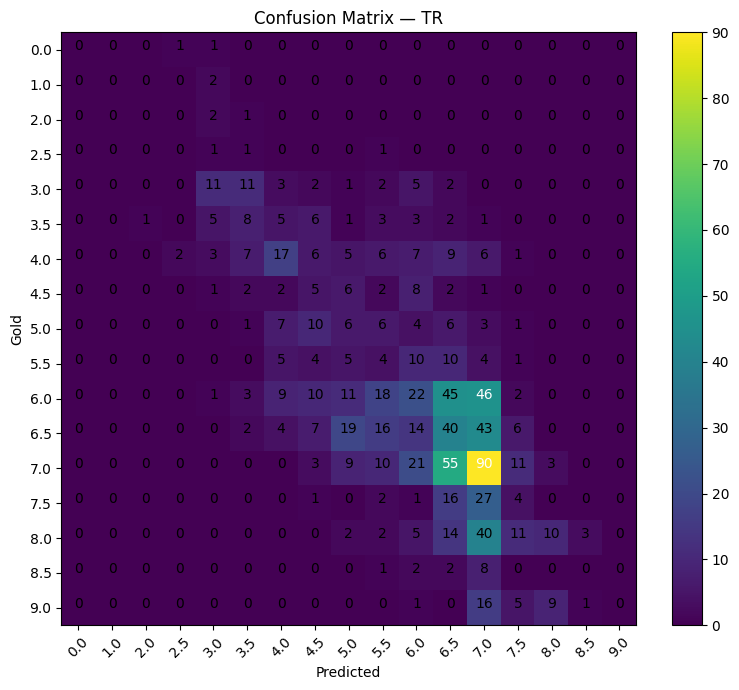


Confusion matrix: CC


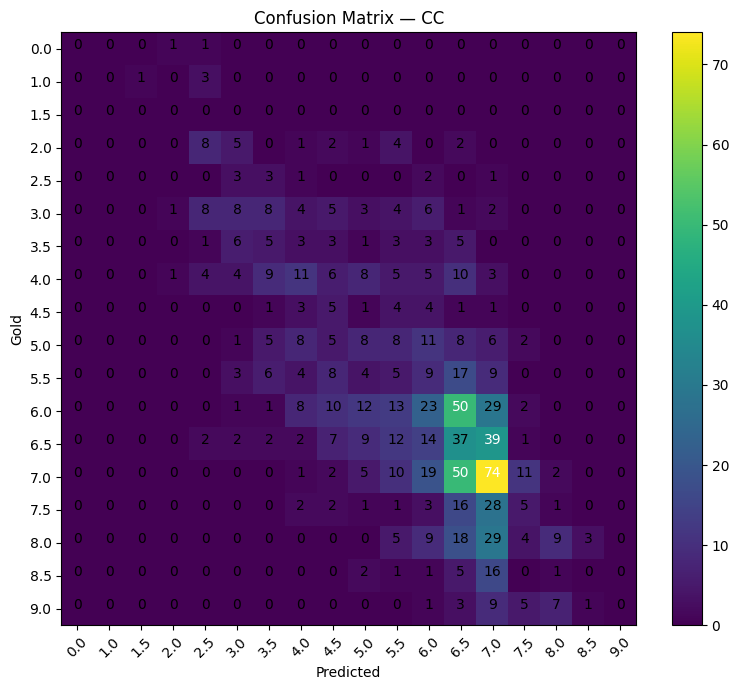


Confusion matrix: LR


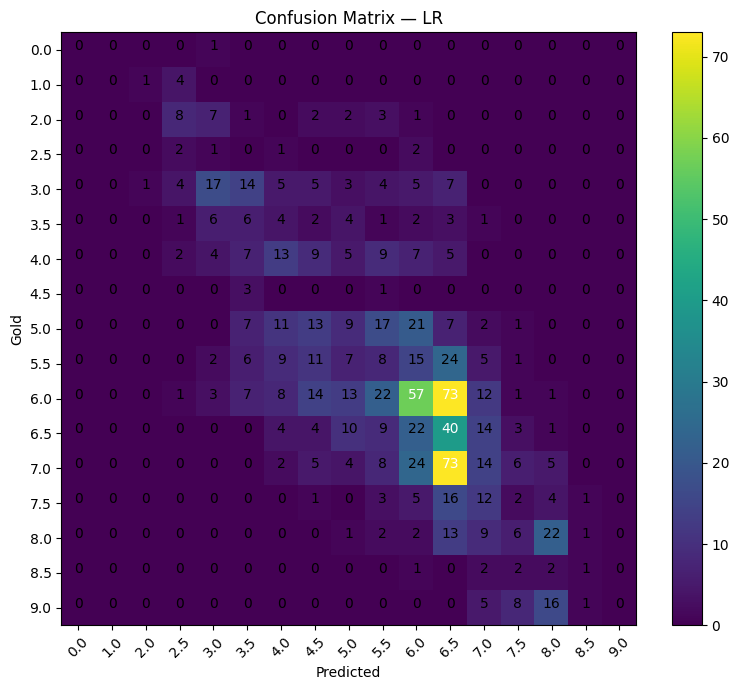


Confusion matrix: GRA


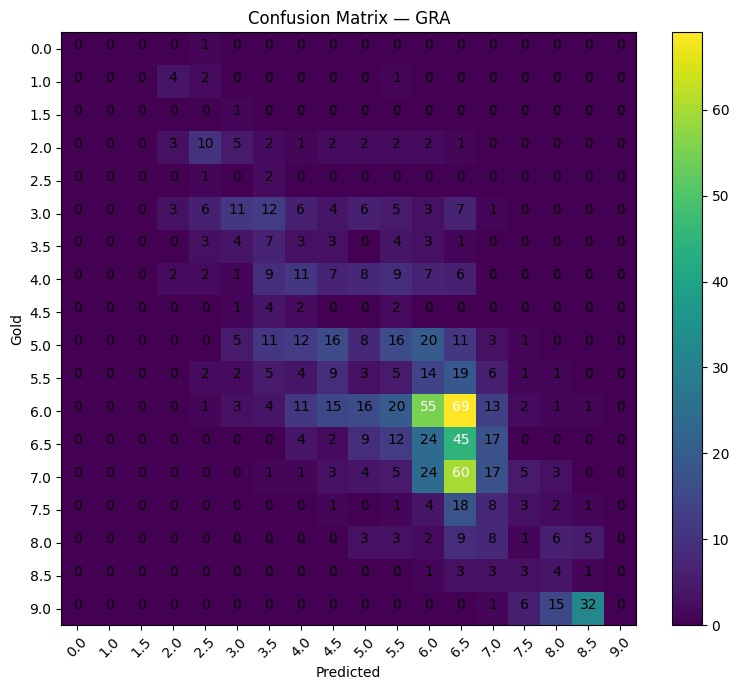


Confusion matrix: Overall derived


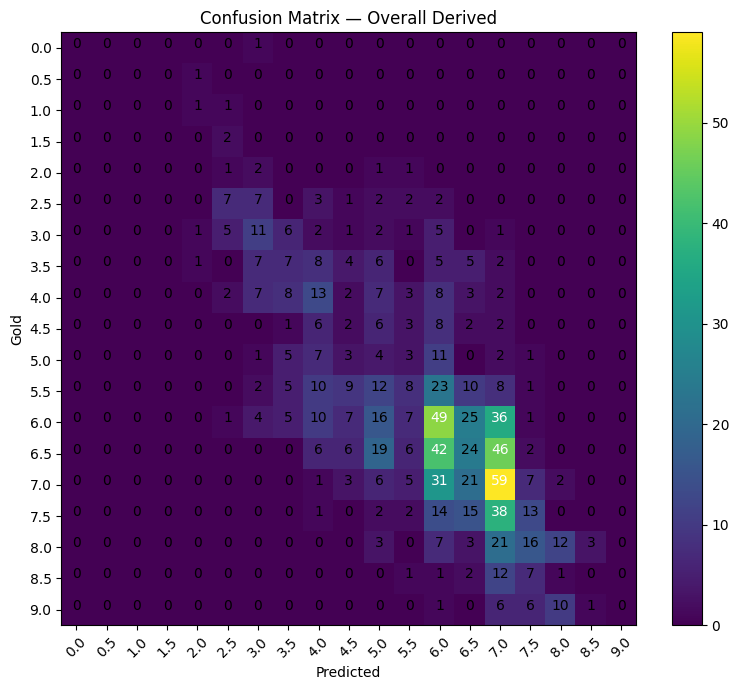

Saved plots to: /content/ielts_qwen_discourse_trait_stacks/plots


In [26]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
import itertools
import os

plot_dir = os.path.join(OUTPUT_DIR, "plots")
os.makedirs(plot_dir, exist_ok=True)

def plot_confusion_matrix_from_bands(y_true_band, y_pred_band, title, save_name=None):
    # Convert band scores to integer classes: 4.0->8, 4.5->9, ...
    y_true_int = np.rint(np.asarray(y_true_band) * 2).astype(int)
    y_pred_int = np.rint(np.asarray(y_pred_band) * 2).astype(int)

    labels = sorted(set(y_true_int).union(set(y_pred_int)))
    cm = confusion_matrix(y_true_int, y_pred_int, labels=labels)

    display_labels = [str(x / 2) for x in labels]

    plt.figure(figsize=(8, 7))
    plt.imshow(cm, interpolation="nearest", aspect="auto")
    plt.title(title)
    plt.colorbar()

    tick_marks = np.arange(len(display_labels))
    plt.xticks(tick_marks, display_labels, rotation=45)
    plt.yticks(tick_marks, display_labels)

    thresh = cm.max() / 2 if cm.max() > 0 else 0
    for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
        plt.text(
            j, i, format(cm[i, j], "d"),
            horizontalalignment="center",
            color="white" if cm[i, j] > thresh else "black"
        )

    plt.ylabel("Gold")
    plt.xlabel("Predicted")
    plt.tight_layout()

    if save_name is not None:
        plt.savefig(os.path.join(plot_dir, save_name), dpi=200, bbox_inches="tight")

    plt.show()


# Vẽ cho từng trait
for trait in TRAIT_COLS:
    print("\n" + "=" * 80)
    print(f"Confusion matrix: {trait}")
    plot_confusion_matrix_from_bands(
        pred_df[f"gold_{trait}"],
        pred_df[f"pred_{trait}"],
        title=f"Confusion Matrix — {trait}",
        save_name=f"confusion_matrix_{trait}.png"
    )

# Vẽ cho Overall derived nếu có
if "gold_Overall" in pred_df.columns:
    valid = ~pd.isna(pred_df["gold_Overall"])
    if valid.any():
        print("\n" + "=" * 80)
        print("Confusion matrix: Overall derived")
        plot_confusion_matrix_from_bands(
            pred_df.loc[valid, "gold_Overall"],
            pred_df.loc[valid, "pred_Overall_derived"],
            title="Confusion Matrix — Overall Derived",
            save_name="confusion_matrix_overall_derived.png"
        )

print("Saved plots to:", plot_dir)

,target,QWK,MAE
0,TR,0.659472,0.852577
1,CC,0.649656,0.955670
2,LR,0.697953,0.865979
3,GRA,0.721045,0.892268
4,Overall_derived,0.691644,0.876289


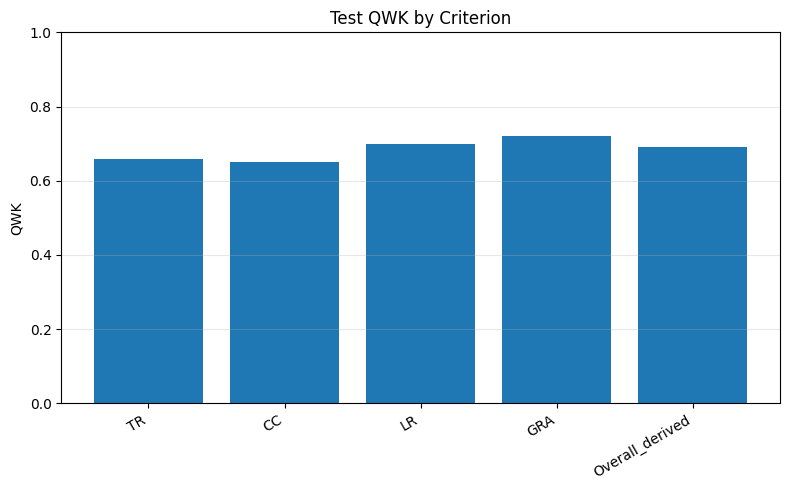

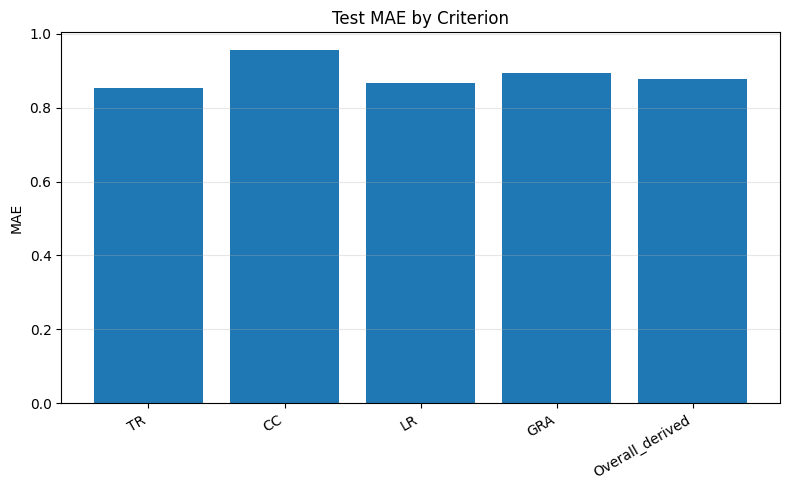

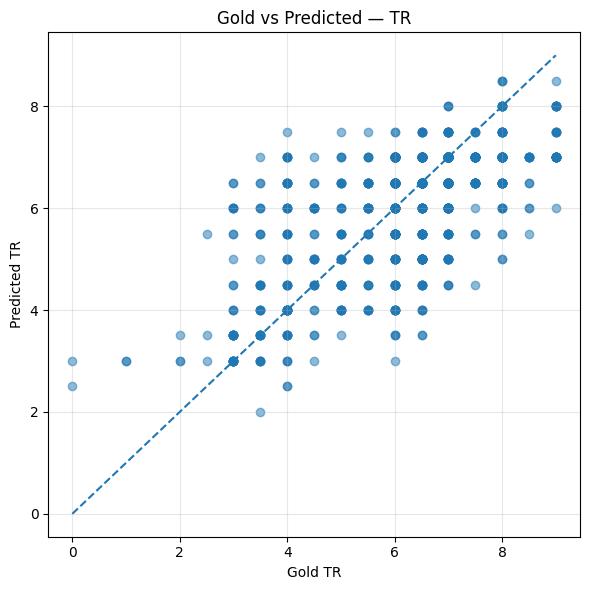

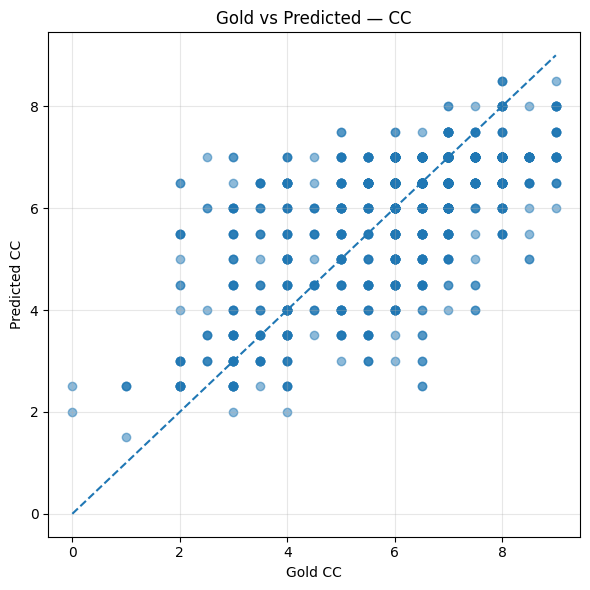

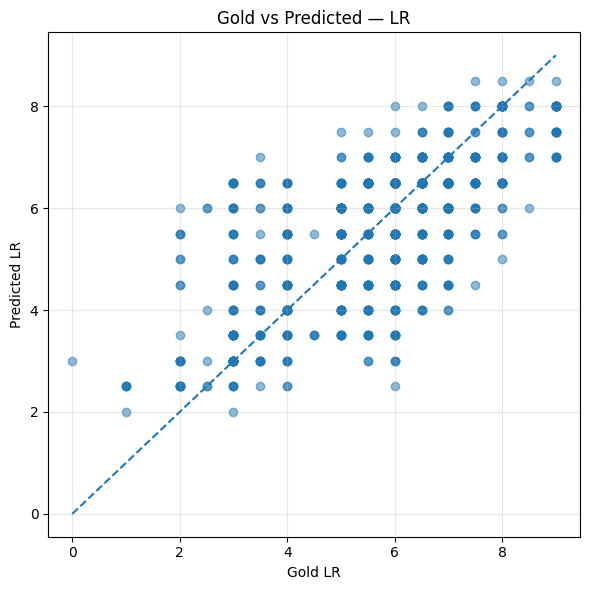

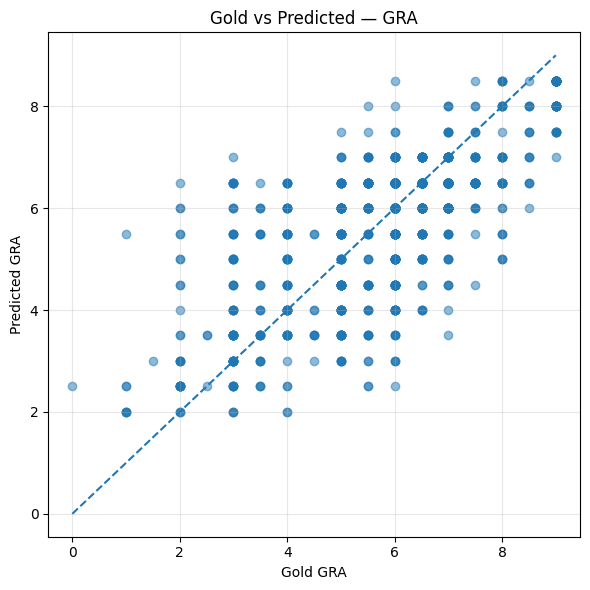

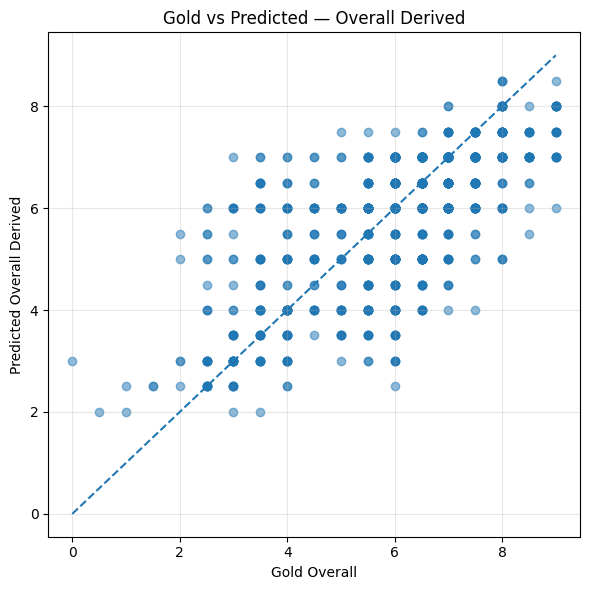

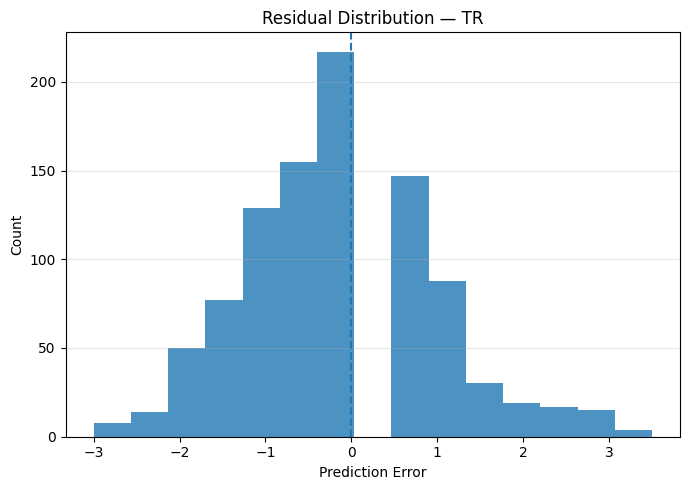

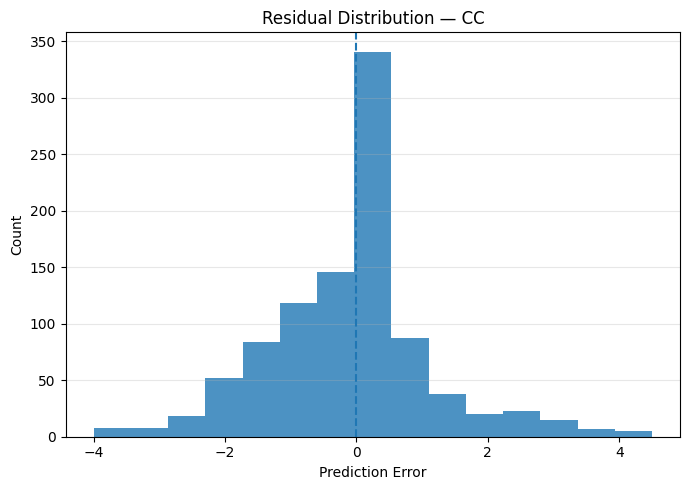

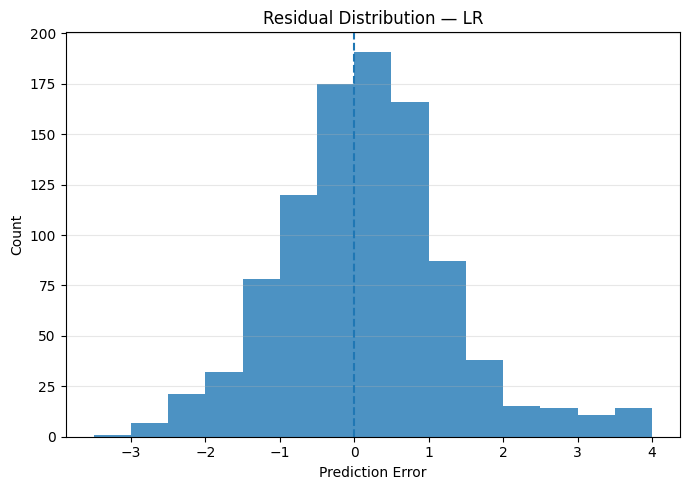

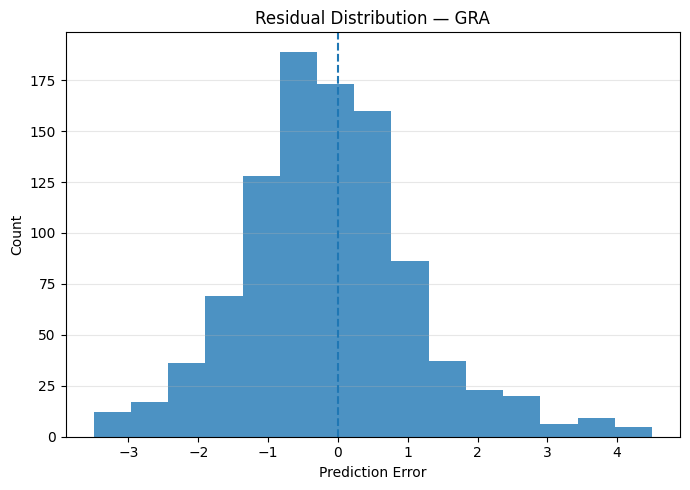

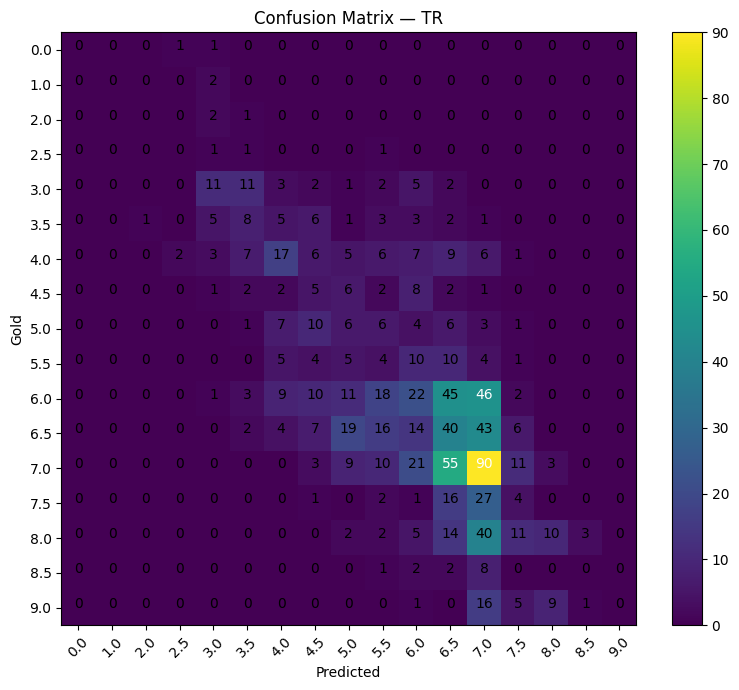

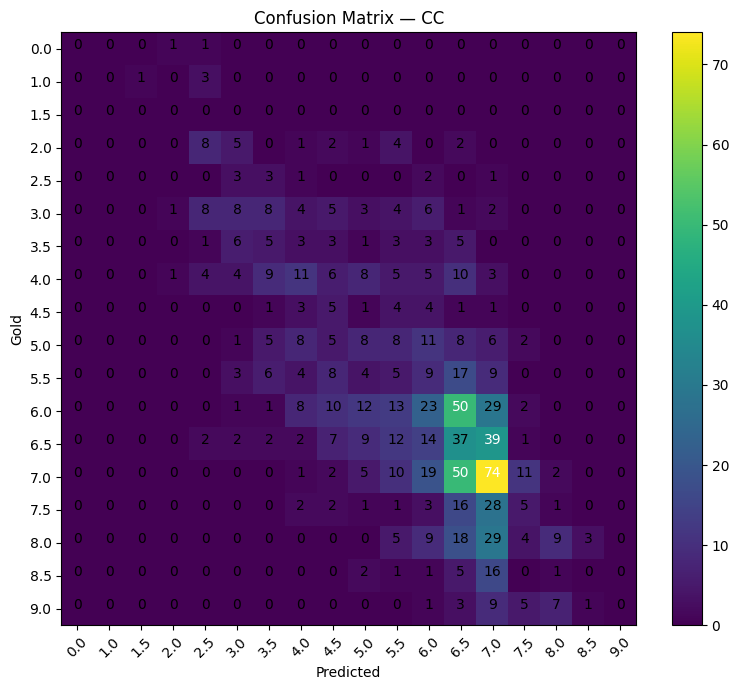

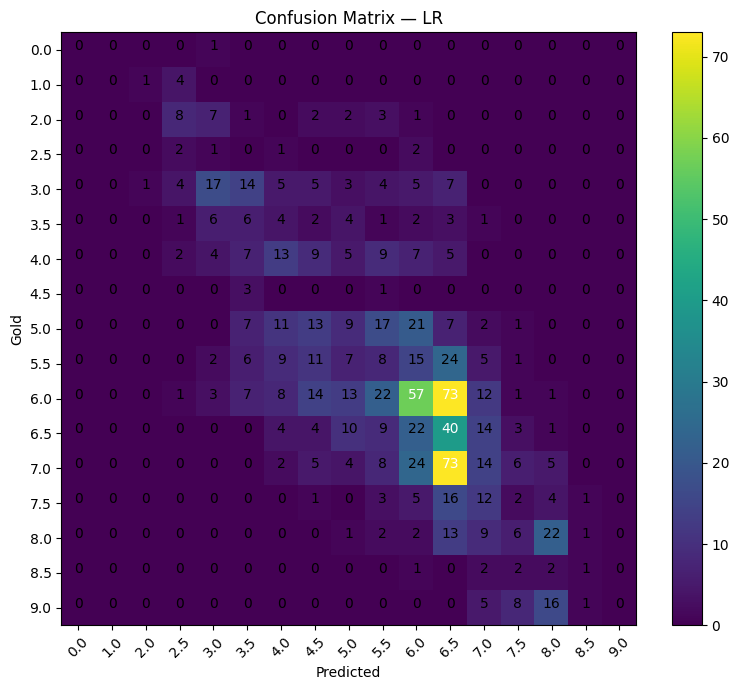

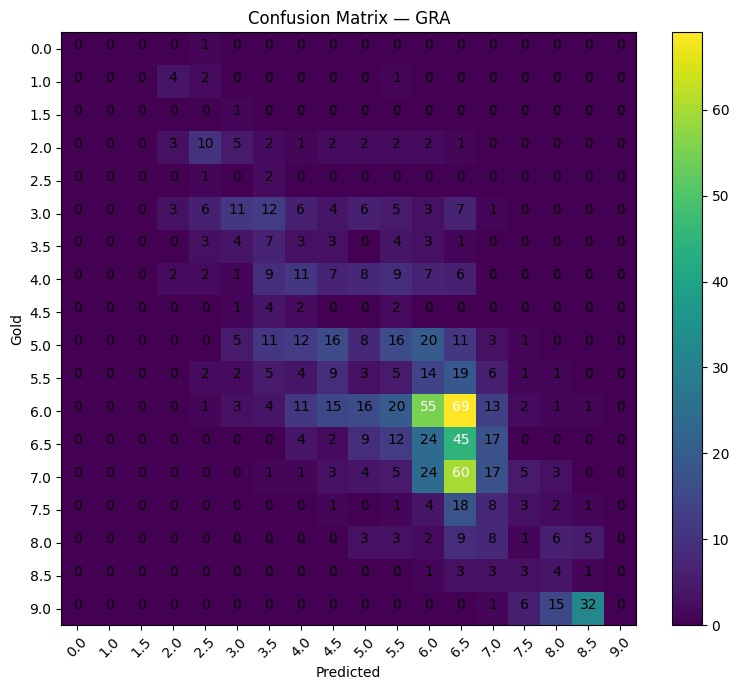

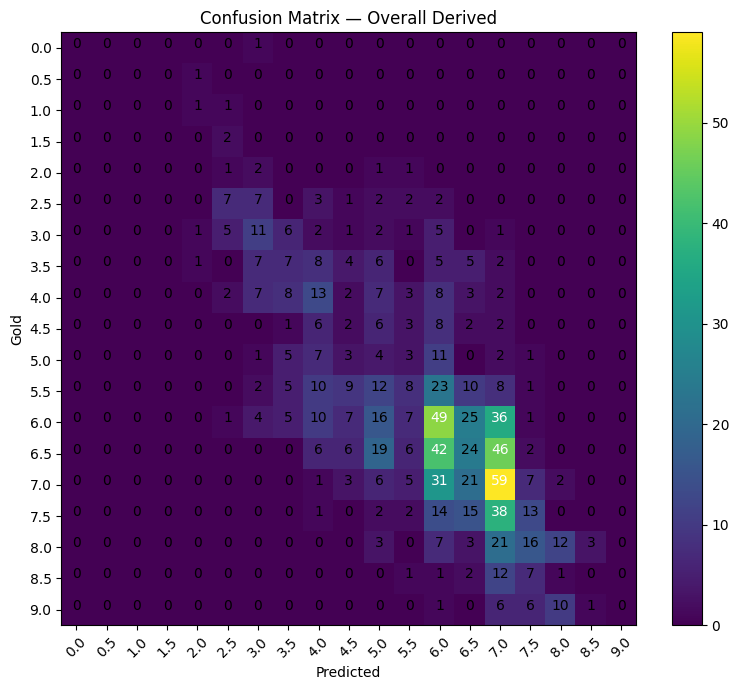

Saved plots to: /content/ielts_qwen_discourse_trait_stacks/plots


In [27]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, confusion_matrix
import itertools

plot_dir = os.path.join(OUTPUT_DIR, "plots")
os.makedirs(plot_dir, exist_ok=True)

summary_rows = []

for trait in TRAIT_COLS:
    qwk = qwk_band(pred_df[f"gold_{trait}"], pred_df[f"pred_{trait}"])
    mae = mean_absolute_error(pred_df[f"gold_{trait}"], pred_df[f"pred_{trait}"])
    summary_rows.append({"target": trait, "QWK": qwk, "MAE": mae})

if "gold_Overall" in pred_df.columns:
    valid = ~pd.isna(pred_df["gold_Overall"])
    if valid.any():
        qwk = qwk_band(pred_df.loc[valid, "gold_Overall"], pred_df.loc[valid, "pred_Overall_derived"])
        mae = mean_absolute_error(pred_df.loc[valid, "gold_Overall"], pred_df.loc[valid, "pred_Overall_derived"])
        summary_rows.append({"target": "Overall_derived", "QWK": qwk, "MAE": mae})

summary_df = pd.DataFrame(summary_rows)
summary_df.to_csv(os.path.join(OUTPUT_DIR, "test_metric_summary.csv"), index=False)
display(summary_df)

plt.figure(figsize=(8, 5))
plt.bar(summary_df["target"], summary_df["QWK"])
plt.ylim(0, 1)
plt.ylabel("QWK")
plt.title("Test QWK by Criterion")
plt.xticks(rotation=30, ha="right")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(plot_dir, "test_qwk_bar.png"), dpi=200)
plt.show()

plt.figure(figsize=(8, 5))
plt.bar(summary_df["target"], summary_df["MAE"])
plt.ylabel("MAE")
plt.title("Test MAE by Criterion")
plt.xticks(rotation=30, ha="right")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(plot_dir, "test_mae_bar.png"), dpi=200)
plt.show()

for trait in TRAIT_COLS:
    plt.figure(figsize=(6, 6))
    x = pred_df[f"gold_{trait}"].values
    y = pred_df[f"pred_{trait}"].values

    plt.scatter(x, y, alpha=0.5)
    min_v = min(np.nanmin(x), np.nanmin(y))
    max_v = max(np.nanmax(x), np.nanmax(y))
    plt.plot([min_v, max_v], [min_v, max_v], linestyle="--")

    plt.xlabel(f"Gold {trait}")
    plt.ylabel(f"Predicted {trait}")
    plt.title(f"Gold vs Predicted — {trait}")
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(os.path.join(plot_dir, f"scatter_gold_pred_{trait}.png"), dpi=200)
    plt.show()

if "gold_Overall" in pred_df.columns:
    valid = ~pd.isna(pred_df["gold_Overall"])
    if valid.any():
        plt.figure(figsize=(6, 6))
        x = pred_df.loc[valid, "gold_Overall"].values
        y = pred_df.loc[valid, "pred_Overall_derived"].values

        plt.scatter(x, y, alpha=0.5)
        min_v = min(np.nanmin(x), np.nanmin(y))
        max_v = max(np.nanmax(x), np.nanmax(y))
        plt.plot([min_v, max_v], [min_v, max_v], linestyle="--")

        plt.xlabel("Gold Overall")
        plt.ylabel("Predicted Overall Derived")
        plt.title("Gold vs Predicted — Overall Derived")
        plt.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.savefig(os.path.join(plot_dir, "scatter_gold_pred_overall_derived.png"), dpi=200)
        plt.show()

for trait in TRAIT_COLS:
    residual = pred_df[f"pred_{trait}"] - pred_df[f"gold_{trait}"]

    plt.figure(figsize=(7, 5))
    plt.hist(residual, bins=15, alpha=0.8)
    plt.axvline(0, linestyle="--")
    plt.xlabel("Prediction Error")
    plt.ylabel("Count")
    plt.title(f"Residual Distribution — {trait}")
    plt.grid(axis="y", alpha=0.3)
    plt.tight_layout()
    plt.savefig(os.path.join(plot_dir, f"residual_hist_{trait}.png"), dpi=200)
    plt.show()

def plot_confusion_matrix_from_bands(y_true_band, y_pred_band, title, save_name):
    y_true_int = np.rint(np.asarray(y_true_band) * 2).astype(int)
    y_pred_int = np.rint(np.asarray(y_pred_band) * 2).astype(int)

    labels = sorted(set(y_true_int).union(set(y_pred_int)))
    cm = confusion_matrix(y_true_int, y_pred_int, labels=labels)
    display_labels = [str(x / 2) for x in labels]

    plt.figure(figsize=(8, 7))
    plt.imshow(cm, interpolation="nearest", aspect="auto")
    plt.title(title)
    plt.colorbar()

    ticks = np.arange(len(display_labels))
    plt.xticks(ticks, display_labels, rotation=45)
    plt.yticks(ticks, display_labels)

    thresh = cm.max() / 2 if cm.max() > 0 else 0
    for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
        plt.text(
            j, i, format(cm[i, j], "d"),
            horizontalalignment="center",
            color="white" if cm[i, j] > thresh else "black"
        )

    plt.ylabel("Gold")
    plt.xlabel("Predicted")
    plt.tight_layout()
    plt.savefig(os.path.join(plot_dir, save_name), dpi=200)
    plt.show()

for trait in TRAIT_COLS:
    plot_confusion_matrix_from_bands(
        pred_df[f"gold_{trait}"],
        pred_df[f"pred_{trait}"],
        f"Confusion Matrix — {trait}",
        f"confusion_matrix_{trait}.png"
    )

if "gold_Overall" in pred_df.columns:
    valid = ~pd.isna(pred_df["gold_Overall"])
    if valid.any():
        plot_confusion_matrix_from_bands(
            pred_df.loc[valid, "gold_Overall"],
            pred_df.loc[valid, "pred_Overall_derived"],
            "Confusion Matrix — Overall Derived",
            "confusion_matrix_overall_derived.png"
        )

print("Saved plots to:", plot_dir)

In [28]:
error_df = pred_df.copy()

for trait in TRAIT_COLS:
    error_df[f"abs_error_{trait}"] = (error_df[f"pred_{trait}"] - error_df[f"gold_{trait}"]).abs()
    error_df[f"signed_error_{trait}"] = error_df[f"pred_{trait}"] - error_df[f"gold_{trait}"]

error_df["mean_abs_trait_error"] = error_df[[f"abs_error_{t}" for t in TRAIT_COLS]].mean(axis=1)

if "gold_Overall" in error_df.columns:
    valid = ~pd.isna(error_df["gold_Overall"])
    error_df["abs_error_Overall_derived"] = np.nan
    error_df.loc[valid, "abs_error_Overall_derived"] = (
        error_df.loc[valid, "pred_Overall_derived"] - error_df.loc[valid, "gold_Overall"]
    ).abs()

hard_cases = error_df.sort_values("mean_abs_trait_error", ascending=False)
hard_cases_path = os.path.join(OUTPUT_DIR, "hard_cases_error_analysis.csv")
hard_cases.to_csv(hard_cases_path, index=False)

print("Saved hard cases:", hard_cases_path)

cols_to_show = [
    "prompt", "essay",
    "gold_TR", "pred_TR", "abs_error_TR",
    "gold_CC", "pred_CC", "abs_error_CC",
    "gold_LR", "pred_LR", "abs_error_LR",
    "gold_GRA", "pred_GRA", "abs_error_GRA",
    "mean_abs_trait_error",
]

if "gold_Overall" in hard_cases.columns:
    cols_to_show += ["gold_Overall", "pred_Overall_derived", "abs_error_Overall_derived"]

display(hard_cases[cols_to_show].head(20))

Saved hard cases: /content/ielts_qwen_discourse_trait_stacks/hard_cases_error_analysis.csv


,prompt,essay,gold_TR,pred_TR,abs_error_TR,gold_CC,pred_CC,abs_error_CC,gold_LR,pred_LR,abs_error_LR,gold_GRA,pred_GRA,abs_error_GRA,mean_abs_trait_error,gold_Overall,pred_Overall_derived,abs_error_Overall_derived
16,Nations should spend more money on skills and ...,Many people dispute that governments should al...,3.0,6.5,3.5,2.0,6.5,4.5,2.0,6.0,4.0,2.0,6.0,4.0,4.000,2.5,6.0,3.5
181,Some people think that instead of preventing c...,Someone believes that we shouldn’t try to avoi...,3.5,7.0,3.5,2.5,7.0,4.5,3.0,6.5,3.5,2.0,6.5,4.5,4.000,3.0,7.0,4.0
824,Young people who commit crimes should be treat...,The number of juvenile delinquencies has been ...,3.0,6.5,3.5,2.0,6.5,4.5,2.5,6.0,3.5,2.0,6.0,4.0,3.875,2.5,6.0,3.5
425,Some people think that the best way to become ...,It is considered that having academic degrees ...,4.0,7.5,3.5,3.0,7.0,4.0,3.5,7.0,3.5,3.0,7.0,4.0,3.750,3.5,7.0,3.5
345,It is important for all towns and cities to ha...,Having big public district including parks and...,3.0,6.0,3.0,2.0,5.5,3.5,2.0,5.5,3.5,1.0,5.5,4.5,3.625,2.0,5.5,3.5
611,Some people believe that studying at universit...,Charge Nurse District Nurse Service Grenville ...,6.0,3.0,3.0,6.5,2.5,4.0,6.0,2.5,3.5,6.0,2.5,3.5,3.500,6.0,2.5,3.5
969,Nowadays celebrities are more famous for their...,Social issues related to celebrities' influenc...,4.0,7.0,3.0,3.0,7.0,4.0,3.0,6.5,3.5,3.0,6.5,3.5,3.500,3.5,7.0,3.5
936,People nowadays tend to have children in older...,The grown-ups nowadays have this decision as p...,3.0,6.0,3.0,2.0,5.5,3.5,2.0,5.5,3.5,2.0,5.5,3.5,3.375,2.5,5.5,3.0
400,The increase in the production of consumer goo...,"Nowadays, various countries developing tend to...",3.0,6.0,3.0,2.0,5.5,3.5,2.0,5.5,3.5,2.0,5.5,3.5,3.375,2.5,5.5,3.0
515,Some people think that teenagers should be req...,A section of society is of the opinion that ad...,7.5,4.5,3.0,7.5,4.0,3.5,7.0,4.0,3.0,7.0,3.5,3.5,3.250,7.5,4.0,3.5


In [29]:
# =========================
# EXPORT BEST CHECKPOINT FROM DISK
# Use this after the current training cell finishes.
# =========================

import os
import json
import shutil
import torch

# Mount Drive if needed
if not os.path.exists("/content/drive/MyDrive"):
    from google.colab import drive
    drive.mount("/content/drive")

EXPORT_DIR = os.path.join(OUTPUT_DIR, "export_lora_best_inference")
os.makedirs(EXPORT_DIR, exist_ok=True)

BEST_ADAPTER_DIR = os.path.join(OUTPUT_DIR, "qwen_lora_adapter")
BEST_STACK_PATH = os.path.join(OUTPUT_DIR, "trait_stacks_and_features.pt")

ADAPTER_DIR = os.path.join(EXPORT_DIR, "qwen_lora_adapter")
TOKENIZER_DIR = os.path.join(EXPORT_DIR, "tokenizer")
STACK_PATH = os.path.join(EXPORT_DIR, "trait_stacks_and_features.pt")
CONFIG_PATH = os.path.join(EXPORT_DIR, "inference_config.json")

if not os.path.exists(BEST_ADAPTER_DIR):
    raise FileNotFoundError(
        f"Best LoRA adapter not found: {BEST_ADAPTER_DIR}. "
        "Có thể training chưa qua epoch validation nào hoặc chưa có [SAVE]."
    )

if not os.path.exists(BEST_STACK_PATH):
    raise FileNotFoundError(
        f"Best stack checkpoint not found: {BEST_STACK_PATH}. "
        "Có thể training chưa qua epoch validation nào hoặc chưa có [SAVE]."
    )

# Copy best LoRA adapter saved by save_checkpoint()
if os.path.exists(ADAPTER_DIR):
    shutil.rmtree(ADAPTER_DIR)
shutil.copytree(BEST_ADAPTER_DIR, ADAPTER_DIR)

# Save tokenizer
if os.path.exists(TOKENIZER_DIR):
    shutil.rmtree(TOKENIZER_DIR)
tokenizer.save_pretrained(TOKENIZER_DIR)

# Copy best trait stacks/projectors/features saved by save_checkpoint()
shutil.copy2(BEST_STACK_PATH, STACK_PATH)

# Save inference config
inference_config = {
    "base_model_name": MODEL_NAME,
    "adapter_dir": "qwen_lora_adapter",
    "tokenizer_dir": "tokenizer",
    "stack_file": "trait_stacks_and_features.pt",
    "trait_cols": TRAIT_COLS,
    "min_band": MIN_BAND,
    "max_band": MAX_BAND,
    "max_length": MAX_LENGTH,
    "feature_hidden": FEATURE_HIDDEN,
    "stack_hidden": STACK_HIDDEN,
    "stack_dropout": STACK_DROPOUT,
    "use_4bit": True,
    "use_handcrafted_features": USE_HANDCRAFTED_FEATURES,
}

with open(CONFIG_PATH, "w", encoding="utf-8") as f:
    json.dump(inference_config, f, indent=2, ensure_ascii=False)

# Copy useful outputs if they exist
for fname in [
    "test_predictions_discourse_trait_stacks.csv",
    "test_metric_summary.csv",
    "hard_cases_error_analysis.csv",
]:
    src = os.path.join(OUTPUT_DIR, fname)
    if os.path.exists(src):
        shutil.copy2(src, os.path.join(EXPORT_DIR, fname))

plot_src = os.path.join(OUTPUT_DIR, "plots")
plot_dst = os.path.join(EXPORT_DIR, "plots")
if os.path.exists(plot_src):
    if os.path.exists(plot_dst):
        shutil.rmtree(plot_dst)
    shutil.copytree(plot_src, plot_dst)

# Zip
zip_base = os.path.join(OUTPUT_DIR, "ielts_lora_BEST_checkpoint_export")
zip_path = shutil.make_archive(zip_base, "zip", EXPORT_DIR)

print("Created best checkpoint zip:", zip_path)

# Copy to Drive
drive_dir = "/content/drive/MyDrive/ielts_model_exports"
os.makedirs(drive_dir, exist_ok=True)

drive_zip_path = os.path.join(drive_dir, os.path.basename(zip_path))
shutil.copy2(zip_path, drive_zip_path)

print("Copied best checkpoint zip to Drive:", drive_zip_path)

Created best checkpoint zip: /content/ielts_qwen_discourse_trait_stacks/ielts_lora_BEST_checkpoint_export.zip
Copied best checkpoint zip to Drive: /content/drive/MyDrive/ielts_model_exports/ielts_lora_BEST_checkpoint_export.zip


In [30]:
import os

drive_zip_path = "/content/drive/MyDrive/ielts_model_exports/ielts_lora_BEST_checkpoint_export.zip"

print("Exists:", os.path.exists(drive_zip_path))
if os.path.exists(drive_zip_path):
    print("Size MB:", os.path.getsize(drive_zip_path) / 1024 / 1024)

Exists: True
Size MB: 124.74989986419678


In [31]:
import os

EXPORT_DIR = os.path.join(OUTPUT_DIR, "export_lora_best_inference")

required_paths = [
    os.path.join(EXPORT_DIR, "qwen_lora_adapter"),
    os.path.join(EXPORT_DIR, "tokenizer"),
    os.path.join(EXPORT_DIR, "trait_stacks_and_features.pt"),
    os.path.join(EXPORT_DIR, "inference_config.json"),
]

for p in required_paths:
    print(p, "OK" if os.path.exists(p) else "MISSING")

/content/ielts_qwen_discourse_trait_stacks/export_lora_best_inference/qwen_lora_adapter OK
/content/ielts_qwen_discourse_trait_stacks/export_lora_best_inference/tokenizer OK
/content/ielts_qwen_discourse_trait_stacks/export_lora_best_inference/trait_stacks_and_features.pt OK
/content/ielts_qwen_discourse_trait_stacks/export_lora_best_inference/inference_config.json OK


## 19. Report wording

Bạn có thể mô tả trong báo cáo:

> We extend the feature-enhanced AES idea of Ait Khayi and Rus (2024) to IELTS multi-criteria scoring. The model combines a trainable Qwen encoder with criterion-specific discourse features inspired by cohesion, lexical chains, connectives, readability, lexical diversity, and syntactic complexity. Instead of predicting a single holistic score, our model uses four criterion-specific stacks for TR, CC, LR, and GRA. The final overall band is deterministically derived by averaging the four predicted criteria and rounding to the nearest half-band.

Nếu dùng LoRA:

> Qwen is fine-tuned using LoRA adapters, while the criterion-specific stacks are trained from scratch.

Nếu dùng full:

> Qwen is fully fine-tuned jointly with the criterion-specific stacks.
